**STEP 1~ STEP 8: 개발 단계, STEP 9 ~ STEP 11: 테스트 단계**

# **STEP 1 - API 연결 및 인증**

In [1]:
from openai import OpenAI
import os
from google.colab import userdata

# API Key 불러오기
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# OpenAI client 생성
client = OpenAI()

# 기존 Vector Store ID 입력
VECTOR_STORE_ID = "vs_6a9d46efb20c81919810d4ef7959f5e8"

# 기존 Vector Store 연결
vector_store = client.vector_stores.retrieve(
    vector_store_id=VECTOR_STORE_ID
)

print("Vector Store 연결 완료")
print("Vector Store ID:", vector_store.id)

Vector Store 연결 완료
Vector Store ID: vs_6a9d46efb20c81919810d4ef7959f5e8


# **STEP 2 - 근거 검색 질의 테스트**

In [2]:
question = "연금가입조건?"

response = client.responses.create(
    model="gpt-4.1-mini",
    input=question,
    instructions="""
당신은 연금 advisor 입니다.

제공된 문서를 기반으로 정확한 답변을 제공해주세요.
관련된 문서를 충분히 검색하고 내용을 종합하여 MECE하게 답변해주세요.

문서에서 확인되지 않는 내용은 추측하지 마세요.
답변 마지막에는 출처 파일명을 작성해주세요.

예:
출처
- 파일명1.pdf
- 파일명2.pdf
""",
    temperature=0.2,
    tools=[
        {
            "type": "file_search",
            "vector_store_ids": [vector_store.id],
            "max_num_results": 10
        }
    ]
)

print(response.output_text)

연금 가입 조건은 다음과 같이 요약할 수 있습니다.

1. 연금 수령 개시 나이: 만 55세 이상이어야 합니다.  
   - IRP 계좌(퇴직금 재원이 이체된 계좌)는 가입 기간과 상관없이 55세 이상이면 연금 수령 개시가 가능합니다.  
   - 일반 연금저축계좌는 가입 기간이 최소 5년 이상이어야 연금 수령이 가능합니다.

2. 가입 기간: 최소 5년 이상 가입해야 합니다.  
   - 단, IRP 계좌는 55세 이상이면 가입 기간 5년 미만이어도 연금 수령 가능.

3. 연금 수령 요건:  
   - 55세 이후 연금 수령 개시 신청 후 인출 가능  
   - 가입일부터 5년 경과 후 인출 가능 (이연퇴직소득이 있는 경우 5년 경과 요건 미적용)  
   - 과세기간 개시일 현재 연금 수령 한도 내에서 인출해야 함

4. 연금 수령 한도 계산:  
   - 연금수령한도 = (과세기간 개시일 현재 평가액 / (11 – 연금수령연차)) × 120%  
   - 연금수령연차는 만 55세와 가입일로부터 5년 경과 동시 충족 시점이 1년차이며, 11년차부터는 연금수령한도 적용이 없습니다.

5. 납입 한도:  
   - 연간 1,800만원 이내 (연금저축 계좌 및 DC/IRP 가입자 납입분 합산)  
   - 세액공제 한도는 연간 최대 600만원 (IRP 포함 최대 900만원)  
   - 세액공제율은 13.2% (총급여 5,500만원 이하 또는 종합소득금액 4,500만원 이하는 16.5%)

6. 중도 인출 가능하나, 중도 해지 또는 계약 종료 후 연금 이외 형태로 수령 시 세액공제 받은 납입 원금과 수익에 대해 기타소득세(16.5%)가 부과될 수 있습니다.

요약하면, 연금 가입자는 만 55세 이상이면서 최소 5년 이상 가입해야 연금 수령이 가능하며, IRP 계좌는 55세 이상이면 가입 기간과 관계없이 연금 수령이 가능합니다. 또한, 연금 수령 시에는 연금 수령 한도 내에서 인출해야 하며, 납입 한도와 세액공제 혜택도 존재합니다.

출처  
- [3교시] 연금

# **STEP 3 - 샘플 고객정보 입력**

In [3]:
customer = """
고객 나이: 62세
당사 계좌 보유: 있음
당사 연금저축: 보유
타 금융회사 연금저축: 있음
타 금융회사 IRP: 보유
퇴직소득 수령: 있음
연금수령: 아직 시작하지 않음
"""

print(customer)


고객 나이: 62세
당사 계좌 보유: 있음
당사 연금저축: 보유
타 금융회사 연금저축: 있음
타 금융회사 IRP: 보유
퇴직소득 수령: 있음
연금수령: 아직 시작하지 않음



# **STEP 4 - 고객 인사이트 및 상담 포인트 생성**

In [10]:
question = f"""
다음 고객에 대해 PB가 실제 상담 전에 활용할 수 있는
Customer Insight와 상담 Point를 작성해주세요.

[고객 정보]
{customer}

[Sales Case 정의]

CASE 1. 신규 연금저축 가입 상담
- 당사 및 타 금융회사에 연금저축을 보유하지 않은 고객

CASE 2. 타사 연금저축 → 당사 연금저축 이전 상담
- 다른 금융회사에 연금저축을 보유한 고객

CASE 3. 타사 IRP → 당사 연금저축 이전 검토
- 만 55세 이상
- 퇴직소득 수령
- 타 금융회사 IRP 보유

연금수령 미개시 등의 정보는 Sales Case가 아니라
추가 상담 기회를 발견하기 위한 Consulting Trigger로 활용하세요.


다음 형식으로 작성해주세요.

### 1. Customer Insight
이 고객의 현재 연금 상황과 상담 기회를
PB가 한눈에 이해할 수 있도록 3문장 이내로 요약

### 2. Sales Opportunity
해당되는 Sales Case를 표시하고
각 Case가 해당되는 고객정보상의 이유를 설명

### 3. Consulting Trigger
고객정보 및 Vector Store 문서에서 발견되는
추가 상담 Trigger를 제시

예:
- 연금수령 미개시
- 과세제외금액 확인 필요
- 연금수령 시점 검토
- 기타 고객에게 의미 있는 연금 상담 포인트

단, 고객정보나 문서에서 확인되지 않는 Trigger는 만들지 마세요.

### 4. PB 상담 Point
PB가 실제 고객과 상담할 때 사용할 수 있도록
우선 확인하거나 설명할 내용을 3~5개 제시

각 항목은 다음 형태로 작성

- 상담 Point:
- 왜 필요한가:
- PB 확인사항:
- 상담 Point는 최대 4개만 제시하고,
  이 고객에게 우선순위가 높은 순서로 작성하세요.

### 5. Marketing Knowledge
Vector Store 문서에서 단순 제도 설명이 아니라,
연금/세제 담당자가 PB에게 제공하는
현장 상담 노하우, 고객 접근 포인트, 마케팅 활용 팁을 찾아 제시하세요.

다음과 같은 내용만 Marketing Knowledge로 인정합니다.

- 특정 고객군에게 먼저 확인하면 좋은 사항
- 고객 상담을 시작하기 좋은 질문 또는 접근 포인트
- 제도상 가능 여부를 넘어 실제 영업현장에서 활용할 수 있는 팁
- 고객에게 설명할 때 강조하면 좋은 포인트
- 고객 관리 또는 후속 상담과 관련한 실무 노하우

아래 내용은 Marketing Knowledge로 분류하지 마세요.

- 법적 가입 요건
- 이전 요건
- 세율
- 연금수령 한도 계산식
- 인출 순서
- 일반적인 제도 설명

관련 Marketing Knowledge가 검색되지 않으면
억지로 생성하지 말고
'관련 Marketing Knowledge 검색되지 않음'이라고 표시하세요.

### 6. Evidence
PB 상담 Point와 Marketing Knowledge에서 사용한
제도·세제 관련 내용의 근거를 반드시 표시하세요.

각 근거는 다음 형식으로 작성하세요.

- 적용 항목:
- 근거 문서:
- 근거 내용:

중요:
- 근거 문서의 실제 파일명을 반드시 표시하세요.
- 검색된 문서에서 근거를 확인하지 못한 내용은
  Evidence에 임의로 작성하지 마세요.
- 근거를 확인하지 못한 제도·세제 내용은
  PB 상담 Point 또는 Marketing Knowledge에서도 단정하지 마세요.
- 근거가 없는 경우 'Vector Store 근거 확인 필요'라고 표시하세요.

### 7. Compliance Check
고객에게 안내하기 전 PB가 확인해야 할
제도·세제·상품 관련 유의사항을 정리


중요:
- 고객정보에 없는 사실은 추측하지 마세요.
- Sales Case와 Consulting Trigger를 구분하세요.
- 실제 가입·이전·연금수령 가능 여부를 단정하지 마세요.
- Marketing Knowledge와 일반 제도 설명을 구분하세요.
- 모든 제도 관련 설명은 Vector Store 문서 근거가 있어야 합니다.
- Sales Case 해당 여부와 실제 제도상 가능 여부를 구분하세요.
- Sales Case 조건에 해당하더라도 실제 이전·가입·연금수령이
  가능하다고 단정하지 마세요.
- 제도·세제 관련 Marketing Knowledge는 반드시 Evidence와 연결하세요.
"""

response = client.responses.create(
    model="gpt-4.1-mini",
    input=question,
    instructions="""
당신은 증권사 PB의 연금 영업과 상담을 지원하는 AI Agent입니다.

목적은 단순히 연금제도를 설명하는 것이 아니라,
고객정보와 회사 내부의 공식 자료 및 Marketing Knowledge를 연결하여
PB가 실제 상담에 활용할 수 있는 Insight를 제공하는 것입니다.

다음 세 가지 정보를 명확하게 구분하세요.

1. Customer Fact
   고객정보에서 확인된 사실

2. Business Opportunity
   회사가 정의한 Sales Case 및 상담 기회

3. Evidence
   Vector Store 문서에서 확인한 제도 및 Marketing Knowledge

고객정보에 없는 내용을 추측하거나
문서 근거가 없는 제도적 판단을 하지 마세요.

PB의 최종 확인이 필요한 사항은 반드시 표시하세요.
""",
    temperature=0.2,
    tools=[
        {
            "type": "file_search",
            "vector_store_ids": [vector_store.id],
            "max_num_results": 10
        }
    ]
)

print(response.output_text)

### 1. Customer Insight
고객은 62세로 당사 및 타 금융회사에 연금저축과 IRP를 보유하고 있으며, 퇴직소득을 이미 수령한 상태입니다. 연금수령은 아직 시작하지 않아 연금 개시 시점과 방법에 대한 상담 기회가 존재합니다. 타사 IRP를 보유하고 있고 퇴직소득 수령 이력이 있어 IRP → 연금저축 이전 상담도 가능합니다.

### 2. Sales Opportunity
- CASE 2. 타사 연금저축 → 당사 연금저축 이전 상담  
  이유: 고객은 타 금융회사에 연금저축을 보유하고 있음.
- CASE 3. 타사 IRP → 당사 연금저축 이전 검토  
  이유: 고객은 만 55세 이상(62세), 퇴직소득 수령, 타 금융회사 IRP 보유 조건을 모두 충족함.

### 3. Consulting Trigger
- 연금수령 미개시: 연금수령을 아직 시작하지 않아 연금 개시 시점 및 인출 계획 상담 필요
- 퇴직소득 수령: 퇴직소득세 및 연금수령 시 세금 이슈 상담 가능
- 연금수령 한도 및 세금 부담: 연금수령 한도 내 인출과 세금 부담에 대한 설명 필요

### 4. PB 상담 Point
- 상담 Point: 타사 IRP → 당사 연금저축 이전 가능 여부 및 절차 확인  
  왜 필요한가: 고객은 타사 IRP를 보유하고 있고 퇴직소득 수령 이력이 있어 이전 조건에 부합함.  
  PB 확인사항: IRP 가입일, 이연퇴직소득 포함 여부, 연금수령 개시 여부 확인 필요  
- 상담 Point: 연금수령 미개시 상태에서 연금 개시 시점과 인출 계획 상담  
  왜 필요한가: 연금수령 시작 시점에 따라 세금 부담과 연금수령 한도가 달라짐  
  PB 확인사항: 고객의 연금 개시 희망 시점, 예상 인출 금액 및 기간  
- 상담 Point: 타사 연금저축 → 당사 연금저축 이전 상담  
  왜 필요한가: 고객이 타사 연금저축을 보유하고 있어 이전을 통한 운용 효율화 가능  
  PB 확인사항: 타사 연금저축 가입일, 잔액, 이전 가능 여부  
- 상담 Poi

# **STEP 5(1) - 상담 유형 선택**

In [ ]:
# ============================================================
# STEP 5-1 · 상담 유형 선택
# STEP 5-2 실행 전에 먼저 실행
# ============================================================

selected_case = """
CASE 3. 타사 IRP → 당사 연금저축 이전 검토
"""

print("선택된 상담 유형:", selected_case.strip())

# **STEP 5(2) - 고객용 제안 문구 생성**

In [65]:
proposal_question = f"""
다음 고객과 PB가 선택한 상담 주제를 바탕으로
고객에게 실제로 전달할 수 있는 1Page 제안서 문구를 작성해주세요.

[고객 정보]
{customer}

[PB가 선택한 상담 주제]
{selected_case}

[작성 목적]
이 문서는 고객에게 직접 전달되는 제안서 초안입니다.
PB 내부 검토용 분석이 아니라 고객이 읽기 쉬운 상담 안내문 형태로 작성하세요.

다음 형식으로 작성해주세요.

### 1. 제안 제목
고객이 부담 없이 읽을 수 있는 제목 1개를 작성하세요.

제목은 상품 가입을 권유하거나 행동을 강하게 유도하지 말고,
고객이 자신의 연금자산을 점검하거나 상담해볼 수 있도록
질문형 또는 확인형 표현을 우선 사용하세요.

예:
- 내 연금자산, 한곳에서 관리할 수 있을까요?
- 다른 금융회사 연금계좌, 이전이 가능한지 확인해보셨나요?

단,
"꼭 확인해보세요",
"지금 이전하세요",
"혜택을 놓치지 마세요"
같은 표현은 사용하지 마세요.

### 2. 고객 상황
고객정보에서 확인된 사실만 활용하여
현재 상황을 2문장 이내로 설명

### 3. 왜 확인해볼 필요가 있을까요?
선택된 상담 주제와 관련하여
고객 입장에서 확인해볼 의미가 있는 이유를 2~3개 제시

단,
- 무조건 유리하다고 표현하지 마세요.
- 절세가 확정된 것처럼 표현하지 마세요.
- 수익률 개선을 보장하지 마세요.

### 4. 상담 시 확인할 내용
PB와 상담할 때 확인해야 할 핵심 사항을 3~4개 제시

예:
- 이전 가능 여부
- 현재 계좌의 상태
- 연금수령 여부
- 세금 및 비용
- 필요한 절차

실제 고객정보와 Vector Store 문서에서 확인되는 내용만 사용하세요.

### 5. 고객에게 안내할 핵심 Point
선택된 상담 주제와 관련하여
고객이 이해하기 쉬운 표현으로 3개 이내로 정리

전문 용어는 최소화하고,
필요한 경우 쉬운 설명을 함께 작성하세요.

### 6. 유의사항
고객에게 반드시 안내해야 하는
세제·이전·상품 관련 유의사항을 작성

다음 원칙을 지키세요.
- 실제 가능 여부는 고객별 조건에 따라 달라질 수 있다고 안내
- 세제 효과를 단정하지 않음
- 상세 내용은 PB를 통해 확인해야 함을 표시
- 상품 가입을 권유하거나 수익을 보장하는 표현 금지

### 7. Evidence
위 제안서에서 사용한 제도 관련 내용의 근거를 표시하세요.

각 근거는 다음 형식으로 작성하세요.

- 적용 내용:
- 근거 문서:
- 근거 내용:

근거 문서의 실제 파일명을 반드시 표시하세요.
Vector Store에서 근거를 확인하지 못한 내용은
고객용 제안서에 포함하지 마세요.

중요:
- 고객정보에 없는 사실을 추측하지 마세요.
- 선택된 상담 주제와 직접 관련 없는 내용은 제외하세요.
- PB 내부용 표현은 사용하지 마세요.
- "반드시", "확실히", "무조건", "절세 가능", "혜택 보장"과 같은
  단정적인 표현은 사용하지 마세요.
- 당사는 IRP 사업을 하지 않으므로
  당사 IRP 가입 또는 당사 IRP로의 이전을 제안하지 마세요.
- 고객용 문구는 "추천", "유리", "효율화", "혜택", "절세"처럼
  고객에게 긍정적 결과가 확정된 것처럼 들릴 수 있는 표현을 피하세요.
- 제목과 본문은 "비교", "확인", "검토", "상담" 중심으로 작성하세요.
- 제목에서 "꼭 확인해보세요", "놓치지 마세요", "지금 확인하세요"처럼
  행동을 강하게 유도하거나 긴급성을 주는 표현을 사용하지 마세요.
- "운용 효율화 가능", "세제 혜택 유지", "더 유리한 관리"처럼
  고객에게 이익이 발생한다고 단정하는 표현은 사용하지 마세요.
- 가입일 유지, 세제 적용, 이전 효과 등 고객별 요건에 따라 달라지는 사항은
  "적용 여부를 확인할 필요가 있습니다",
  "고객별 조건에 따라 달라질 수 있습니다",
  "상담을 통해 검토할 수 있습니다"와 같이 표현하세요.
- "퇴직소득 수령: 있음"과 같이 고객정보가 과거 이력인지
  현재 진행 중인지 명확하지 않은 경우
  "수령한 이력이 있음"처럼 확인된 사실 범위 내에서 표현하세요.
- 연령, 가입기간, 이연퇴직소득 등 여러 조건에 따라
  예외가 존재할 수 있는 제도 요건은 일부 조건만 떼어
  일반적인 필수요건처럼 단정하지 마세요.
  고객용 문구에서는 "고객별 계좌 조건에 따라 달라질 수 있음"으로 표현하고,
  구체적인 요건은 상담 시 확인하도록 안내하세요.
- 당사는 IRP 사업을 하지 않습니다.
  따라서 당사 IRP 가입 또는 당사 IRP로의 이전을 제안하지 마세요.
  이 내용은 Agent가 지켜야 할 내부 업무 규칙이며,
  고객용 제안서에는 해당 내용을 출력하지 마세요.
"""

proposal_response = client.responses.create(
    model="gpt-4.1-mini",
    input=proposal_question,
    instructions="""
당신은 증권사 PB가 고객에게 전달할
연금 상담 제안서 초안을 작성하는 AI Agent입니다.

목적은 고객에게 상품 가입을 강하게 권유하는 것이 아니라,
고객의 현재 연금 상황에서 확인해볼 상담 주제를
사내 공식 문서 근거를 바탕으로 쉽고 정확하게 설명하는 것입니다.

다음 원칙을 반드시 지키세요.

1. Customer Fact
고객정보에서 확인된 사실만 사용

2. Selected Opportunity
PB가 선택한 상담 주제만 다룸

3. Evidence
제도·세제 관련 설명은 반드시 Vector Store 근거를 사용

4. Compliance
실제 이전·연금수령·세제 적용 가능 여부는
고객별 요건 확인 전까지 단정하지 않음

5. Customer-friendly
내부 업무 용어보다 고객이 이해하기 쉬운 표현을 사용

6. Neutral Tone
고객용 문구는 비교·확인·검토 중심으로 작성하고,
고객에게 이익이 확정된 것처럼 보이는 표현은 피하세요.

근거를 찾지 못한 내용은 억지로 작성하지 마세요.
""",
    temperature=0.2,
    tools=[
        {
            "type": "file_search",
            "vector_store_ids": [vector_store.id],
            "max_num_results": 10
        }
    ]
)

print(proposal_response.output_text)

### 1. 제안 제목  
다른 금융회사 IRP 자산, 연금저축 계좌로 이전해볼 수 있을까요?

### 2. 고객 상황  
김연금 고객님은 당사에 연금저축 계좌를 보유하고 계시며, 타 금융회사에 연금저축과 IRP 계좌도 보유하고 있습니다. 타사 IRP는 가입기간이 5년 미만이며, 퇴직소득을 수령한 이력이 있습니다.

### 3. 왜 확인해볼 필요가 있을까요?  
- 타사 IRP 자산을 당사 연금저축 계좌로 이전할 수 있는지 여부를 확인함으로써 자산 관리 현황을 점검할 수 있습니다.  
- 이전 시 가입기간 유지 여부와 세제 적용 조건이 고객별로 달라질 수 있으므로, 상담을 통해 구체적인 적용 가능성을 검토할 수 있습니다.  
- 이전 과정에서 발생할 수 있는 절차와 비용, 연금 수령 계획과의 연계성 등을 함께 살펴볼 수 있습니다.

### 4. 상담 시 확인할 내용  
- 타사 IRP에서 당사 연금저축 계좌로 이전이 가능한지 여부  
- 이전 시 가입기간 유지 및 세제 적용 조건  
- 현재 보유 중인 타사 IRP 및 당사 연금저축 계좌의 상태  
- 이전 절차와 예상 소요 기간, 관련 비용 및 세금 처리  
- 연금 수령 시작 시점과 연계한 세제 및 인출 전략

### 5. 고객에게 안내할 핵심 Point  
- 타사 IRP 자산은 당사 연금저축 계좌로 이전 신청이 가능할 수 있으나, 고객별 계좌 조건에 따라 다를 수 있습니다.  
- 이전 시 가입기간을 유지할 수 있는지, 세제 혜택이 어떻게 적용되는지는 상담을 통해 확인해야 합니다.  
- 이전 절차 진행 중에는 해당 계좌에서 추가 납입이나 매매가 제한될 수 있으므로 이 점도 함께 고려하셔야 합니다.

### 6. 유의사항  
- 타사 IRP에서 당사 연금저축 계좌로의 이전 가능 여부와 세제 적용은 고객별 계좌 조건 및 가입기간 등에 따라 달라질 수 있으므로, 구체적인 사항은 상담을 통해 확인해야 합니다.  
- 이전 과정에서 자산 매각 및 현금화가 필요할 수 있으며, 이로 인해 투자 수익률 변동 가능성이

## **STEP 6 — Card News + SMS 생성**

In [66]:
# ============================================
# STEP 6. Card News + SMS 생성 Agent
# 신규 생성 + PB 수정 요청 자동 처리
# ============================================

import json
import copy


# ------------------------------------------------
# 1. 담당 PB
# ------------------------------------------------

pb_name = "홍길동"


# ------------------------------------------------
# 2. Structured Output Schema
# ------------------------------------------------

content_schema = {

    "type": "json_schema",

    "name": "pension_marketing_content",

    "strict": True,

    "schema": {

        "type": "object",

        "properties": {

            "card1": {
                "type": "object",
                "properties": {
                    "title": {"type": "string"},
                    "body": {"type": "string"}
                },
                "required": [
                    "title",
                    "body"
                ],
                "additionalProperties": False
            },

            "card2": {
                "type": "object",
                "properties": {
                    "title": {"type": "string"},
                    "body": {"type": "string"}
                },
                "required": [
                    "title",
                    "body"
                ],
                "additionalProperties": False
            },

            "card3": {
                "type": "object",
                "properties": {
                    "title": {"type": "string"},
                    "body": {"type": "string"},
                    "cta": {"type": "string"}
                },
                "required": [
                    "title",
                    "body",
                    "cta"
                ],
                "additionalProperties": False
            },

            "sms": {
                "type": "string"
            },

            "compliance": {
                "type": "string"
            },

            "evidence": {

                "type": "array",

                "items": {

                    "type": "object",

                    "properties": {

                        "applied_content": {
                            "type": "string"
                        },

                        "source_file": {
                            "type": "string"
                        },

                        "source_detail": {
                            "type": "string"
                        }
                    },

                    "required": [
                        "applied_content",
                        "source_file",
                        "source_detail"
                    ],

                    "additionalProperties": False
                }
            }
        },

        "required": [
            "card1",
            "card2",
            "card3",
            "sms",
            "compliance",
            "evidence"
        ],

        "additionalProperties": False
    }
}


# ------------------------------------------------
# 3. 신규 콘텐츠 생성 함수
# ------------------------------------------------

def generate_new_cardnews():

    prompt = f"""
다음 고객정보와 PB가 선택한 상담 주제를 바탕으로
고객에게 전달할 수 있는
3컷 Card News와 SMS를 작성해주세요.

[고객 정보]
{customer}

[상담 주제]
{selected_case}

[담당 PB]
{pb_name} PB


[목적]

상품 가입을 직접 권유하는 것이 아니라,
고객이 자신의 연금자산을 점검하고
필요한 경우 PB에게 편하게 문의할 수 있도록 돕는 것입니다.


===============================
CARD 1
===============================

고객의 관심을 자연스럽게 유도하세요.

- 짧은 제목
- 본문 최대 2문장
- 개인정보 직접 노출 금지
- 상품 가입 직접 권유 금지
- 긴급성 표현 금지


===============================
CARD 2
===============================

선택된 상담 주제와 관련하여
고객이 알아두면 좋은 내용을 쉽게 설명하세요.

- 본문 최대 2~3문장
- Vector Store 근거가 있는 내용만 사용

연령, 가입기간, 이연퇴직소득 여부,
연금수령 상태 등 세부 요건은
고객용 Card News에 직접 나열하지 마세요.

다음 수준으로 단순화하세요.

"일정한 요건에 따라 검토할 수 있습니다."

"실제 가능 여부는 고객별 계좌 조건에 따라
달라질 수 있습니다."


===============================
CARD 3
===============================

PB 상담으로 자연스럽게 연결하세요.

- 질문형 제목 권장
- 본문 최대 2문장
- 반드시 {pb_name} PB 이름 사용
- 가입 권유 금지
- 긴급성 금지


===============================
SMS
===============================

- 3~4문장 이내
- 개인정보 노출 금지
- 비교·확인·검토 중심
- {pb_name} PB 이름 사용

"고객별 조건에 따라 실제 적용 여부가
달라질 수 있음"을 자연스럽게 안내하세요.

"상담을 권해드립니다"보다는

"궁금하시면 상담을 통해 확인할 수 있습니다."
"{pb_name} PB에게 편하게 문의해 주세요."

처럼 표현하세요.


===============================
Compliance
===============================

1~2문장으로 작성하세요.

실제 이전 가능 여부,
세제 적용,
기타 제도 적용은
고객별 계좌 조건에 따라 달라질 수 있으며
상담을 통해 확인해야 한다고 안내하세요.


===============================
Evidence
===============================

Card News와 SMS에서 사용한
제도 관련 내용의 Vector Store 근거를
PB 내부 검증용으로 작성하세요.

- 적용 내용
- 실제 근거 문서 파일명
- 근거 내용


===============================
중요
===============================

고객정보에 없는 사실을 추측하지 마세요.

실제 이전 가능 여부를 단정하지 마세요.

예외가 있는 제도의 일부 요건만 떼어
일반적인 필수요건처럼 표현하지 마세요.

고객용 문구는
비교·확인·검토·상담 중심으로 작성하세요.

"절세됩니다"
"유리합니다"
"추천합니다"
"혜택을 받을 수 있습니다"
"꼭 확인하세요"
"지금 신청하세요"

등의 표현을 사용하지 마세요.

당사는 IRP 사업을 하지 않습니다.
따라서 당사 IRP 가입 또는
당사 IRP로의 이전은 제안하지 마세요.

이 내용은 내부 업무규칙이며
고객용 콘텐츠에는 출력하지 마세요.
"""


    response = client.responses.create(

        model="gpt-4.1-mini",

        input=prompt,

        instructions="""
당신은 증권사 PB의 고객 커뮤니케이션을 지원하는 AI Agent입니다.

고객정보에 없는 사실을 만들지 않습니다.

제도 및 세제 설명은
Vector Store 근거가 확인된 경우에만 사용합니다.

고객용 콘텐츠와
PB 내부 Evidence를 명확히 분리합니다.

고객 메시지는
비교·확인·검토·상담 중심으로 작성합니다.
""",

        temperature=0.2,

        tools=[
            {
                "type": "file_search",
                "vector_store_ids": [
                    vector_store.id
                ],
                "max_num_results": 10
            }
        ],

        text={
            "format": content_schema
        }
    )


    return json.loads(
        response.output_text
    )


# ------------------------------------------------
# 4. SMS만 수정하는 함수
# ------------------------------------------------

def revise_sms(
    existing_data,
    revision_request
):

    old_sms = existing_data["sms"]


    prompt = f"""
다음은 현재 고객용 SMS입니다.

[기존 SMS]
{old_sms}


[PB 수정 요청]
{revision_request}


[담당 PB]
{pb_name} PB


PB 수정 요청에 맞게
기존 SMS를 실제로 수정하세요.

중요:

- 기존 SMS를 그대로 반복하지 마세요.
- PB 수정 요청이 결과에서 명확하게 확인되어야 합니다.
- 기존 SMS의 금융·제도적 의미는 유지하세요.
- 새로운 금융·세제 사실을 추가하지 마세요.
- 3~4문장 이내로 작성하세요.
- 개인정보를 직접 노출하지 마세요.
- 가입을 강하게 권유하지 마세요.
- 경제적 효과를 단정하지 마세요.
- 비교·확인·검토 중심으로 작성하세요.
- {pb_name} PB 이름을 사용하세요.

수정된 SMS 문구만 출력하세요.
"""


    response = client.responses.create(

        model="gpt-4.1-mini",

        input=prompt,

        instructions="""
당신은 금융상품 고객 SMS를
PB의 수정 요청에 맞게 편집하는 역할입니다.

기존 문장을 그대로 반복하지 말고
수정 요청을 실제 결과에 반영하세요.

새로운 금융·세제 사실을 추가하지 마세요.
""",

        temperature=0.4
    )


    revised_sms = (
        response.output_text.strip()
    )


    # 동일 문구 방지
    if revised_sms == old_sms.strip():

        retry_prompt = f"""
기존 SMS와 동일한 문장을 반환하면 안 됩니다.

[기존 SMS]
{old_sms}

[PB 수정 요청]
{revision_request}

PB 요청이 명확히 드러나도록
문장 구조와 표현을 실제로 변경하세요.

새로운 금융·세제 사실은 추가하지 마세요.

수정된 SMS만 출력하세요.
"""


        retry_response = client.responses.create(

            model="gpt-4.1-mini",

            input=retry_prompt,

            temperature=0.6
        )


        revised_sms = (
            retry_response.output_text.strip()
        )


    new_data = copy.deepcopy(
        existing_data
    )

    new_data["sms"] = revised_sms


    return new_data


# ------------------------------------------------
# 5. 전체 콘텐츠 수정 함수
# ------------------------------------------------

def revise_full_content(
    existing_data,
    revision_request
):

    previous_text = json.dumps(
        existing_data,
        ensure_ascii=False,
        indent=2
    )


    prompt = f"""
다음은 기존 고객 커뮤니케이션 초안입니다.

[기존 초안]
{previous_text}


[PB 수정 요청]
{revision_request}


PB 수정 요청에 해당하는 영역을
실제로 수정하세요.

수정 요청과 관계없는 영역은
가능한 한 기존 내용을 유지하세요.

새로운 금융·세제 사실은
임의로 추가하지 마세요.
"""


    response = client.responses.create(

        model="gpt-4.1-mini",

        input=prompt,

        instructions="""
PB의 수정 요청을 기존 초안에 반영합니다.

수정 요청과 관련된 영역만 우선 수정하고
나머지는 최대한 유지하세요.

새로운 금융·세제 사실을 추가하지 마세요.
""",

        temperature=0.4,

        text={
            "format": content_schema
        }
    )


    return json.loads(
        response.output_text
    )


# ------------------------------------------------
# 6. PB 수정 요청 자동 처리 함수
# ------------------------------------------------

def regenerate_from_pb_feedback(
    existing_data,
    revision_request
):

    revision_lower = (
        revision_request
        .lower()
        .strip()
    )


    # SMS 수정 요청인지 판별
    sms_request = (
        "sms" in revision_lower
        or "문자" in revision_lower
        or "메시지" in revision_lower
    )


    if sms_request:

        print("🔄 SMS 수정 요청을 처리합니다.")

        return revise_sms(
            existing_data,
            revision_request
        )


    else:

        print("🔄 콘텐츠 수정 요청을 처리합니다.")

        return revise_full_content(
            existing_data,
            revision_request
        )


# ------------------------------------------------
# 7. 최초 실행
# ------------------------------------------------

cardnews_data = generate_new_cardnews()


# ------------------------------------------------
# 8. 전역 변수 업데이트
# ------------------------------------------------

sms_text = cardnews_data["sms"]

compliance_text = (
    cardnews_data["compliance"]
)

evidence_data = (
    cardnews_data["evidence"]
)


# ------------------------------------------------
# 9. 출력
# ------------------------------------------------

print("✅ STEP 6 신규 콘텐츠 생성 완료")


print("\nCARD 1")
print(cardnews_data["card1"]["title"])
print(cardnews_data["card1"]["body"])


print("\nCARD 2")
print(cardnews_data["card2"]["title"])
print(cardnews_data["card2"]["body"])


print("\nCARD 3")
print(cardnews_data["card3"]["title"])
print(cardnews_data["card3"]["body"])
print(cardnews_data["card3"]["cta"])


print("\nSMS")
print(cardnews_data["sms"])


print("\nCompliance")
print(cardnews_data["compliance"])


print("\nEvidence")

for evidence in cardnews_data["evidence"]:

    print(
        "\n- 적용 내용:",
        evidence["applied_content"]
    )

    print(
        "- 근거 문서:",
        evidence["source_file"]
    )

    print(
        "- 근거 내용:",
        evidence["source_detail"]
    )

✅ STEP 6 신규 콘텐츠 생성 완료

CARD 1
연금자산 점검, 생각해보셨나요?
타사 IRP 자산을 당사 연금저축으로 이전하는 것도 한 방법입니다. 자신의 연금 현황을 한 번 더 확인해 보세요.

CARD 2
타사 IRP → 당사 연금저축 이전, 어떻게?
일정한 요건에 따라 타사 IRP에서 당사 연금저축으로 이전을 검토할 수 있습니다. 다만, 실제 가능 여부는 고객별 계좌 조건에 따라 달라질 수 있습니다.

CARD 3
이전 절차, 궁금하지 않으신가요?
이전 절차와 조건에 대해 홍길동 PB가 자세히 안내해 드립니다. 궁금한 점이 있으면 언제든 편하게 문의해 주세요.
홍길동 PB에게 문의하기

SMS
안녕하세요, 김연금 고객님. 타사 IRP 자산을 당사 연금저축으로 이전하는 것은 일정 조건 하에 검토 가능합니다. 다만, 고객님 계좌별 조건에 따라 실제 적용 여부가 다를 수 있으니 궁금하시면 홍길동 PB에게 편하게 문의해 주세요.

Compliance
타사 IRP에서 당사 연금저축으로의 이전 가능 여부와 세제 적용 등은 고객별 계좌 조건에 따라 달라질 수 있으므로 상담을 통해 확인해야 합니다.

Evidence

- 적용 내용: 일정한 요건에 따라 타사 IRP에서 당사 연금저축으로 이전을 검토할 수 있으며, 실제 가능 여부는 고객별 계좌 조건에 따라 달라질 수 있음.
- 근거 문서: 연금스쿨 강의 후 배포 자료_2026_3분기_20260827.pdf
- 근거 내용: 타사 IRP 연금저축 이전 절차 및 조건 설명, 이체 절차 안내 부분

- 적용 내용: 이전용 계좌 개설 시 '전부 이전을 위한 개설'로 하여 이체하는 계좌의 가입일을 선택할 수 있음.
- 근거 문서: 연금계좌 세제혜택 활용하기_상품솔루션부_20260312.pdf
- 근거 내용: MTS를 통한 연금저축펀드 이전 관련 설명


## **STEP 7 - 카드뉴스 시각화**

In [41]:
# 한글 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null 2>&1

print("한글 폰트 설치 완료")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
한글 폰트 설치 완료


In [24]:
import glob

nanum_fonts = glob.glob(
    "/usr/share/fonts/truetype/nanum/*.ttf"
)

print("설치된 Nanum 폰트:")

for f in nanum_fonts:
    print(f)

설치된 Nanum 폰트:
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf
/usr/share/fonts/truetype/nanum/NanumGothic.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf


✅ STEP 6 → STEP 7 데이터 연결 완료

✅ Card News 이미지 생성 완료
/content/pension_cardnews/card_1.png
/content/pension_cardnews/card_2.png
/content/pension_cardnews/card_3.png


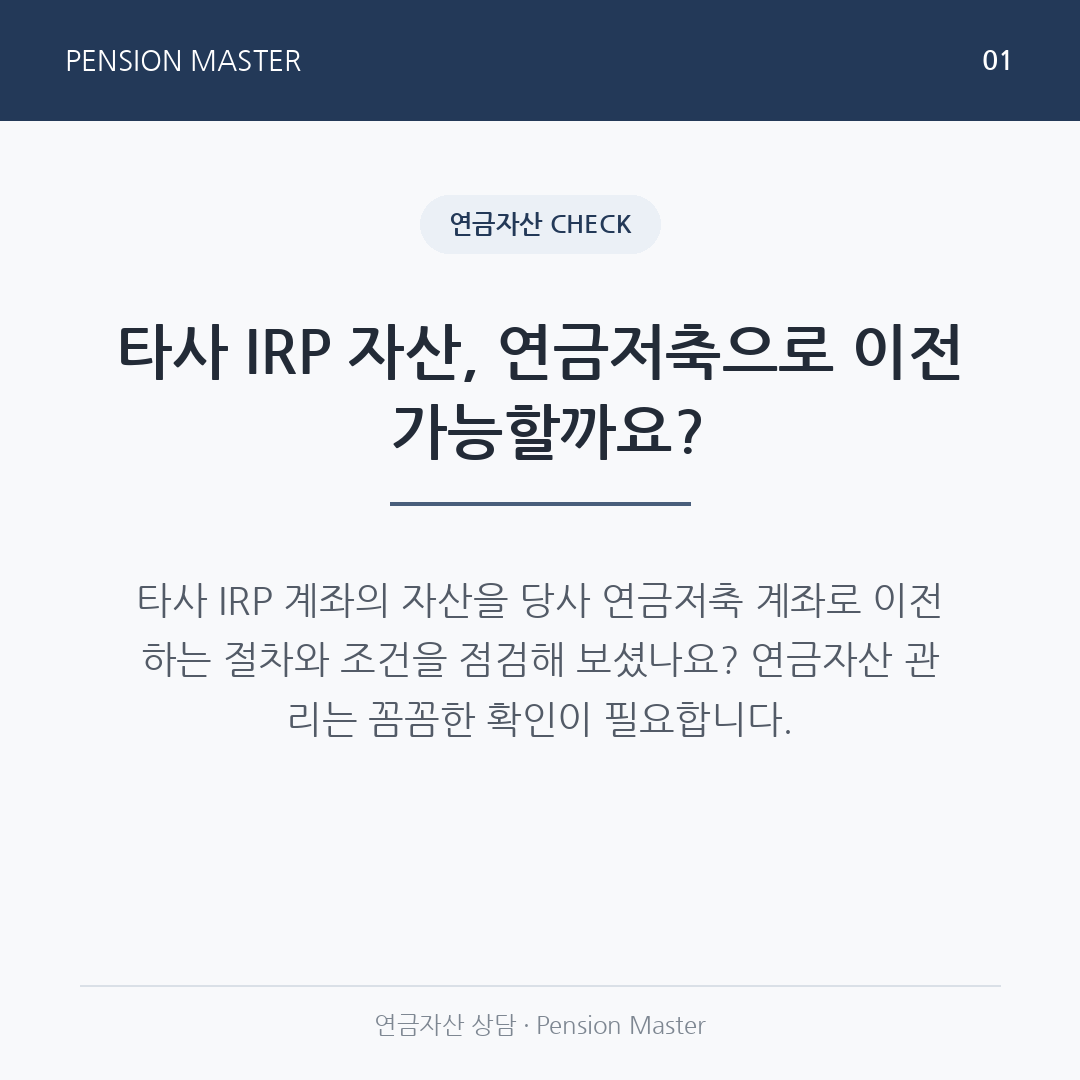

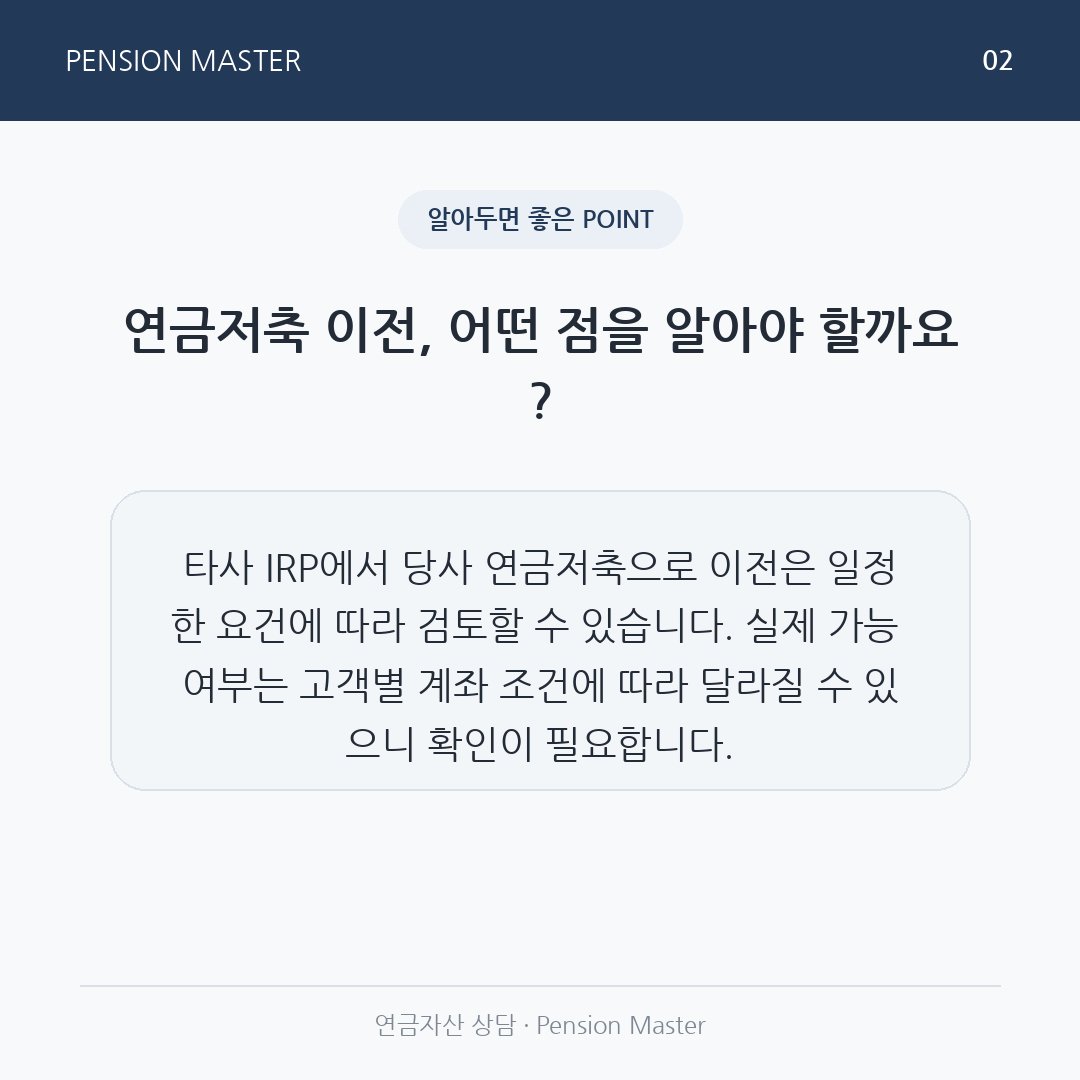

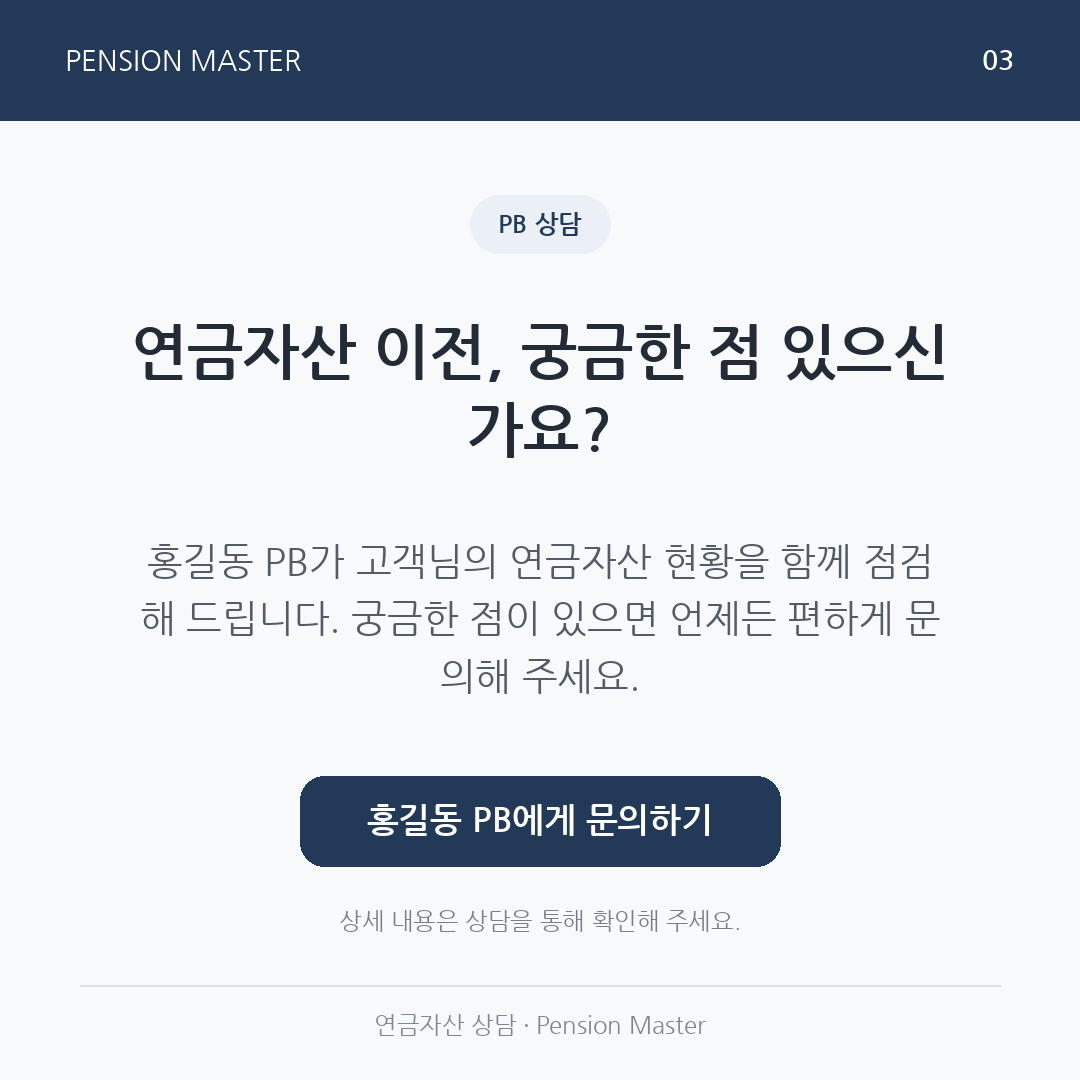


📩 SMS
타사 IRP에서 당사 연금저축으로의 이전은 일정한 요건에 따라 검토할 수 있습니다. 다만, 실제 적용 여부는 고객별 계좌 조건에 따라 달라질 수 있으니 홍길동 PB에게 편하게 문의하시면 자세히 확인해 드리겠습니다.

⚠️ Compliance
타사 IRP에서 당사 연금저축으로의 이전 가능 여부 및 세제 적용 등은 고객별 계좌 조건에 따라 달라질 수 있으며, 상담을 통해 확인해야 합니다.

🔎 Evidence — PB 내부 검증용

[Evidence 1]
적용 내용: IRP에서 연금저축으로의 이전은 전액 이전이 필요하며, 가입자의 연령과 가입기간 등 일정 요건을 충족해야 합니다. 실제 가능 여부는 고객별 계좌 조건에 따라 달라질 수 있습니다.
근거 문서: IRP 이전 및 인출(ver.4)_투자솔루션본부_20260126.pdf
근거 내용: IRP → 연금저축 이전 조건 및 절차 설명, 1~7항 내용 요약

[Evidence 2]
적용 내용: 연금계좌 이전은 일정한 요건에 따라 가능하며, 실제 적용 여부는 고객별 계좌 조건에 따라 달라질 수 있음을 안내합니다.
근거 문서: 연금계좌 세제혜택 활용하기_상품솔루션부_20260312.pdf
근거 내용: 연금계좌 이전 가능 여부 및 조건 설명, 21페이지 내용

✅ STEP 7 완료
STEP 6 AI 결과 → Card News 이미지 자동 변환 성공


In [42]:
# ============================================
# STEP 7. STEP 6 결과 → Card News 자동 시각화
# ============================================

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import os


# ------------------------------------------------
# 1. STEP 6 결과 자동 연결
# ------------------------------------------------

card1_title = cardnews_data["card1"]["title"]
card1_text = cardnews_data["card1"]["body"]

card2_title = cardnews_data["card2"]["title"]
card2_text = cardnews_data["card2"]["body"]

card3_title = cardnews_data["card3"]["title"]
card3_text = cardnews_data["card3"]["body"]
card3_cta = cardnews_data["card3"]["cta"]

sms_text = cardnews_data["sms"]
compliance_text = cardnews_data["compliance"]
evidence_data = cardnews_data["evidence"]

print("✅ STEP 6 → STEP 7 데이터 연결 완료")


# ------------------------------------------------
# 2. 저장 폴더
# ------------------------------------------------

OUTPUT_DIR = "/content/pension_cardnews"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ------------------------------------------------
# 3. 카드 크기
# ------------------------------------------------

WIDTH = 1080
HEIGHT = 1080


# ------------------------------------------------
# 4. 한글 폰트
# ------------------------------------------------

regular_font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
bold_font_path = "/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf"

if not os.path.exists(regular_font_path):
    raise FileNotFoundError(
        f"Regular 폰트를 찾을 수 없습니다: {regular_font_path}"
    )

if not os.path.exists(bold_font_path):
    raise FileNotFoundError(
        f"Bold 폰트를 찾을 수 없습니다: {bold_font_path}"
    )


# ------------------------------------------------
# 5. 폰트 크기
# ------------------------------------------------

font_brand = ImageFont.truetype(regular_font_path, 28)
font_card_num = ImageFont.truetype(bold_font_path, 27)

font_badge = ImageFont.truetype(bold_font_path, 25)

font_title_large = ImageFont.truetype(bold_font_path, 60)
font_title = ImageFont.truetype(bold_font_path, 50)

font_body = ImageFont.truetype(regular_font_path, 38)
font_body_bold = ImageFont.truetype(bold_font_path, 38)

font_button = ImageFont.truetype(bold_font_path, 34)
font_footer = ImageFont.truetype(regular_font_path, 24)


# ------------------------------------------------
# 6. 색상
# ------------------------------------------------

NAVY = (35, 57, 88)
NAVY_LIGHT = (73, 94, 123)

TEXT = (35, 43, 55)
TEXT_LIGHT = (83, 91, 103)

BACKGROUND = (248, 249, 251)
WHITE = (255, 255, 255)

LIGHT_BOX = (235, 240, 246)
LIGHTER_BOX = (243, 246, 249)

BORDER = (218, 224, 231)


# ------------------------------------------------
# 7. 텍스트 크기 계산
# ------------------------------------------------

def get_text_size(draw, text, font):

    bbox = draw.textbbox(
        (0, 0),
        text,
        font=font
    )

    return (
        bbox[2] - bbox[0],
        bbox[3] - bbox[1]
    )


# ------------------------------------------------
# 8. 한글 자동 줄바꿈
# ------------------------------------------------

def wrap_korean_text(
    draw,
    text,
    font,
    max_width
):

    paragraphs = text.split("\n")

    final_lines = []

    for paragraph in paragraphs:

        paragraph = paragraph.strip()

        if paragraph == "":
            final_lines.append("")
            continue

        current_line = ""

        for char in paragraph:

            candidate = current_line + char

            width, _ = get_text_size(
                draw,
                candidate,
                font
            )

            if width <= max_width:

                current_line = candidate

            else:

                if current_line:
                    final_lines.append(current_line)

                current_line = char

        if current_line:
            final_lines.append(current_line)

    return final_lines


# ------------------------------------------------
# 9. 중앙 정렬 텍스트
# ------------------------------------------------

def draw_center_text(
    draw,
    text,
    font,
    start_y,
    fill=TEXT,
    max_width=850,
    line_spacing=20
):

    lines = wrap_korean_text(
        draw,
        text,
        font,
        max_width
    )

    y = start_y

    for line in lines:

        if line == "":

            y += 35
            continue

        w, h = get_text_size(
            draw,
            line,
            font
        )

        x = (WIDTH - w) / 2

        draw.text(
            (x, y),
            line,
            font=font,
            fill=fill
        )

        y += h + line_spacing

    return y


# ------------------------------------------------
# 10. 공통 Header
# ------------------------------------------------

def draw_header(
    draw,
    card_number
):

    draw.rectangle(
        [(0, 0), (WIDTH, 120)],
        fill=NAVY
    )

    draw.text(
        (65, 44),
        "PENSION MASTER",
        font=font_brand,
        fill=WHITE
    )

    number_text = f"{card_number:02d}"

    w, _ = get_text_size(
        draw,
        number_text,
        font_card_num
    )

    draw.text(
        (WIDTH - w - 65, 44),
        number_text,
        font=font_card_num,
        fill=WHITE
    )


# ------------------------------------------------
# 11. 공통 Footer
# ------------------------------------------------

def draw_footer(
    draw,
    text="연금자산 상담 · Pension Master"
):

    draw.line(
        [(80, 985), (1000, 985)],
        fill=BORDER,
        width=2
    )

    w, _ = get_text_size(
        draw,
        text,
        font_footer
    )

    draw.text(
        (
            (WIDTH - w) / 2,
            1010
        ),
        text,
        font=font_footer,
        fill=(126, 135, 146)
    )


# ------------------------------------------------
# 12. Badge 생성 함수
# ------------------------------------------------

def draw_badge(
    draw,
    badge_text,
    y=195
):

    badge_w, badge_h = get_text_size(
        draw,
        badge_text,
        font_badge
    )

    x1 = (WIDTH - badge_w) / 2 - 28
    x2 = (WIDTH + badge_w) / 2 + 28

    draw.rounded_rectangle(
        [
            (x1, y),
            (x2, y + 58)
        ],
        radius=29,
        fill=LIGHT_BOX
    )

    draw.text(
        (
            (WIDTH - badge_w) / 2,
            y + 14
        ),
        badge_text,
        font=font_badge,
        fill=NAVY
    )


# ------------------------------------------------
# 13. CARD 1 생성
# 관심 유도
# ------------------------------------------------

def create_card1():

    image = Image.new(
        "RGB",
        (WIDTH, HEIGHT),
        BACKGROUND
    )

    draw = ImageDraw.Draw(image)

    draw_header(draw, 1)

    draw_badge(
        draw,
        "연금자산 CHECK",
        y=195
    )


    # AI가 만든 제목
    y = draw_center_text(
        draw,
        card1_title,
        font_title_large,
        start_y=315,
        fill=TEXT,
        max_width=850,
        line_spacing=22
    )


    # 강조 라인
    draw.line(
        [
            (390, y + 30),
            (690, y + 30)
        ],
        fill=NAVY_LIGHT,
        width=4
    )


    # AI가 만든 본문
    draw_center_text(
        draw,
        card1_text,
        font_body,
        start_y=y + 105,
        fill=TEXT_LIGHT,
        max_width=830,
        line_spacing=24
    )


    draw_footer(draw)


    path = os.path.join(
        OUTPUT_DIR,
        "card_1.png"
    )

    image.save(path)

    return image, path


# ------------------------------------------------
# 14. CARD 2 생성
# 정보 제공
# ------------------------------------------------

def create_card2():

    image = Image.new(
        "RGB",
        (WIDTH, HEIGHT),
        BACKGROUND
    )

    draw = ImageDraw.Draw(image)

    draw_header(draw, 2)

    draw_badge(
        draw,
        "알아두면 좋은 POINT",
        y=190
    )


    # AI가 만든 제목
    y = draw_center_text(
        draw,
        card2_title,
        font_title,
        start_y=300,
        fill=TEXT,
        max_width=850,
        line_spacing=22
    )


    # 정보 박스 위치
    box_top = y + 60
    box_bottom = box_top + 300


    draw.rounded_rectangle(
        [
            (110, box_top),
            (970, box_bottom)
        ],
        radius=35,
        fill=LIGHTER_BOX,
        outline=BORDER,
        width=2
    )


    # AI가 만든 본문
    draw_center_text(
        draw,
        card2_text,
        font_body,
        start_y=box_top + 55,
        fill=TEXT,
        max_width=750,
        line_spacing=23
    )


    draw_footer(draw)


    path = os.path.join(
        OUTPUT_DIR,
        "card_2.png"
    )

    image.save(path)

    return image, path


# ------------------------------------------------
# 15. CARD 3 생성
# 상담 연결
# ------------------------------------------------

def create_card3():

    image = Image.new(
        "RGB",
        (WIDTH, HEIGHT),
        BACKGROUND
    )

    draw = ImageDraw.Draw(image)

    draw_header(draw, 3)

    draw_badge(
        draw,
        "PB 상담",
        y=195
    )


    # AI가 만든 제목
    y = draw_center_text(
        draw,
        card3_title,
        font_title_large,
        start_y=315,
        fill=TEXT,
        max_width=820,
        line_spacing=20
    )


    # AI가 만든 본문
    y2 = draw_center_text(
        draw,
        card3_text,
        font_body,
        start_y=y + 70,
        fill=TEXT_LIGHT,
        max_width=820,
        line_spacing=22
    )


    # CTA 버튼
    button_text = card3_cta

    button_w, button_h = get_text_size(
        draw,
        button_text,
        font_button
    )

    button_width = max(
        button_w + 100,
        480
    )

    button_x1 = (WIDTH - button_width) / 2
    button_x2 = (WIDTH + button_width) / 2

    button_y1 = y2 + 65
    button_y2 = button_y1 + 90


    draw.rounded_rectangle(
        [
            (button_x1, button_y1),
            (button_x2, button_y2)
        ],
        radius=24,
        fill=NAVY
    )


    draw.text(
        (
            (WIDTH - button_w) / 2,
            button_y1 + 23
        ),
        button_text,
        font=font_button,
        fill=WHITE
    )


    # 간단 유의문구
    note = "상세 내용은 상담을 통해 확인해 주세요."

    note_w, _ = get_text_size(
        draw,
        note,
        font_footer
    )

    draw.text(
        (
            (WIDTH - note_w) / 2,
            button_y2 + 40
        ),
        note,
        font=font_footer,
        fill=(120, 128, 138)
    )


    draw_footer(draw)


    path = os.path.join(
        OUTPUT_DIR,
        "card_3.png"
    )

    image.save(path)

    return image, path


# ------------------------------------------------
# 16. 카드뉴스 생성
# ------------------------------------------------

card1, path1 = create_card1()
card2, path2 = create_card2()
card3, path3 = create_card3()


# ------------------------------------------------
# 17. 결과 출력
# ------------------------------------------------

print("\n✅ Card News 이미지 생성 완료")
print(path1)
print(path2)
print(path3)


display(card1)
display(card2)
display(card3)


# ------------------------------------------------
# 18. SMS 미리보기
# ------------------------------------------------

print("\n" + "=" * 70)
print("📩 SMS")
print("=" * 70)

print(sms_text)


# ------------------------------------------------
# 19. Compliance 미리보기
# ------------------------------------------------

print("\n" + "=" * 70)
print("⚠️ Compliance")
print("=" * 70)

print(compliance_text)


# ------------------------------------------------
# 20. Evidence 미리보기
# ------------------------------------------------

print("\n" + "=" * 70)
print("🔎 Evidence — PB 내부 검증용")
print("=" * 70)

for i, evidence in enumerate(
    evidence_data,
    start=1
):

    print(f"\n[Evidence {i}]")

    print(
        "적용 내용:",
        evidence["applied_content"]
    )

    print(
        "근거 문서:",
        evidence["source_file"]
    )

    print(
        "근거 내용:",
        evidence["source_detail"]
    )


# ------------------------------------------------
# 21. 최종 실행 완료 메시지
# ------------------------------------------------

print("\n" + "=" * 70)

print("✅ STEP 7 완료")
print("STEP 6 AI 결과 → Card News 이미지 자동 변환 성공")

print("=" * 70)

# **STEP 8 - PB 검토 · 승인 · 발송 Prototype**

In [43]:
# ============================================
# STEP 8. PB Review
# 승인 + AI 자동 수정 + 이미지 자동 재생성
# ============================================

import os
import copy

from datetime import datetime

import ipywidgets as widgets

from IPython.display import (
    display,
    HTML,
    clear_output
)


# ------------------------------------------------
# 1. 필수 변수 확인
# ------------------------------------------------

required_vars = [

    "cardnews_data",

    "path1",
    "path2",
    "path3",

    "sms_text",
    "compliance_text",
    "evidence_data",

    "pb_name",
    "selected_case",

    "regenerate_from_pb_feedback",

    "create_card1",
    "create_card2",
    "create_card3"
]


missing_vars = [

    var

    for var in required_vars

    if var not in globals()
]


if missing_vars:

    raise NameError(
        "STEP 6과 STEP 7을 먼저 실행해주세요.\n"
        f"없는 변수: {missing_vars}"
    )


# ------------------------------------------------
# 2. 상태
# ------------------------------------------------

review_state = {

    "status": "대기",

    "approved": False,

    "sent": False,

    "reviewed_by": None,

    "reviewed_at": None,

    "sent_at": None,

    "memo": "",

    "revision_count": 0
}


# ------------------------------------------------
# 3. Style
# ------------------------------------------------

display(
    HTML(
        """
<style>

.pm-title {
    font-size: 28px;
    font-weight: 700;
    color: #233958;
    margin-bottom: 5px;
}

.pm-subtitle {
    font-size: 15px;
    color: #6b7280;
    margin-bottom: 22px;
}

.pm-section {
    font-size: 20px;
    font-weight: 700;
    color: #233958;
    margin-top: 28px;
    margin-bottom: 12px;
}

.pm-box {
    border: 1px solid #d9dee7;
    border-radius: 12px;
    padding: 18px;
    background-color: #fafbfc;
    margin-bottom: 15px;
}

.pm-evidence {
    border-left: 4px solid #596f8f;
    padding: 12px 18px;
    margin-bottom: 12px;
    background-color: #f6f8fa;
}

.pm-ok {
    color: #1f7a4d;
    font-weight: 700;
}

.pm-warning {
    color: #8a6d1d;
    font-weight: 700;
}

.pm-error {
    color: #b42318;
    font-weight: 700;
}

</style>
"""
    )
)


# ------------------------------------------------
# 4. Header
# ------------------------------------------------

display(
    HTML(
        """
<div class="pm-title">
    Pension Master · PB Review
</div>

<div class="pm-subtitle">
    AI 생성 → Evidence 확인 → PB 검토 →
    AI 수정 → 승인 → 발송
</div>
"""
    )
)


display(
    HTML(
        f"""
<div class="pm-section">
    ① 상담 Opportunity
</div>

<div class="pm-box">

    <b>선택 상담 주제</b><br>
    {selected_case.strip()}

    <br><br>

    <b>담당 PB</b><br>
    {pb_name} PB

</div>
"""
    )
)


# ------------------------------------------------
# 5. Card News 영역
# ------------------------------------------------

display(
    HTML(
        """
<div class="pm-section">
    ② 고객 발송용 Card News
</div>
"""
    )
)


card_output = widgets.Output()

display(card_output)


# ------------------------------------------------
# 6. SMS
# ------------------------------------------------

display(
    HTML(
        """
<div class="pm-section">
    ③ SMS
</div>
"""
    )
)


sms_box = widgets.Textarea(

    value=cardnews_data["sms"],

    layout=widgets.Layout(
        width="100%",
        height="130px"
    )
)


display(sms_box)


# ------------------------------------------------
# 7. Compliance
# ------------------------------------------------

display(
    HTML(
        """
<div class="pm-section">
    ④ Compliance
</div>
"""
    )
)


compliance_output = widgets.Output()

display(compliance_output)


# ------------------------------------------------
# 8. Evidence
# ------------------------------------------------

display(
    HTML(
        """
<div class="pm-section">
    ⑤ PB Evidence
</div>

<div class="pm-subtitle">
    고객에게 발송되지 않는 내부 검증 영역입니다.
</div>
"""
    )
)


evidence_output = widgets.Output()

display(evidence_output)


# ------------------------------------------------
# 9. 화면 갱신 함수
# ------------------------------------------------

def refresh_review_screen():

    # --------------------------------------------
    # Card News 갱신
    # --------------------------------------------

    with card_output:

        clear_output(wait=True)


        images = []


        for path in [
            path1,
            path2,
            path3
        ]:

            with open(
                path,
                "rb"
            ) as file:

                images.append(

                    widgets.Image(

                        value=file.read(),

                        format="png",

                        width=300,

                        height=300
                    )
                )


        display(

            widgets.HBox(

                images,

                layout=widgets.Layout(

                    display="flex",

                    justify_content="space-around",

                    width="100%"
                )
            )
        )


    # --------------------------------------------
    # SMS 갱신
    # --------------------------------------------

    sms_box.value = (
        cardnews_data["sms"]
    )


    # --------------------------------------------
    # Compliance 갱신
    # --------------------------------------------

    with compliance_output:

        clear_output(wait=True)

        display(
            HTML(
                f"""
<div class="pm-box">
    {cardnews_data["compliance"]}
</div>
"""
            )
        )


    # --------------------------------------------
    # Evidence 갱신
    # --------------------------------------------

    with evidence_output:

        clear_output(wait=True)


        for i, evidence in enumerate(
            cardnews_data["evidence"],
            start=1
        ):

            display(
                HTML(
                    f"""
<div class="pm-evidence">

    <b>Evidence {i}</b>

    <br><br>

    <b>적용 내용</b><br>
    {evidence["applied_content"]}

    <br><br>

    <b>근거 문서</b><br>
    {evidence["source_file"]}

    <br><br>

    <b>근거 내용</b><br>
    {evidence["source_detail"]}

</div>
"""
                )
            )


# ------------------------------------------------
# 10. 최초 화면 출력
# ------------------------------------------------

refresh_review_screen()


# ------------------------------------------------
# 11. PB 검토
# ------------------------------------------------

display(
    HTML(
        """
<div class="pm-section">
    ⑥ PB 최종 검토
</div>
"""
    )
)


check_content = widgets.Checkbox(
    description="고객용 문구 확인"
)

check_evidence = widgets.Checkbox(
    description="Evidence 확인"
)

check_compliance = widgets.Checkbox(
    description="Compliance 확인"
)

check_customer = widgets.Checkbox(
    description="고객별 실제 적용 여부 별도 확인"
)


display(
    check_content,
    check_evidence,
    check_compliance,
    check_customer
)


# ------------------------------------------------
# 12. PB 수정 요청
# ------------------------------------------------

display(
    HTML(
        """
<br>
<b>PB 검토 메모 / AI 수정 요청</b>

<br>

<span style="color:#6b7280;">
예: SMS에서 '타사 IRP' 표현을 줄이고
연금자산 점검 중심으로 부드럽게 수정해주세요.
</span>
"""
    )
)


review_memo = widgets.Textarea(

    placeholder=(
        "AI에게 수정할 내용을 입력하세요."
    ),

    layout=widgets.Layout(
        width="100%",
        height="110px"
    )
)


display(review_memo)


# ------------------------------------------------
# 13. 상태창
# ------------------------------------------------

status_output = widgets.Output()

display(status_output)


def show_status(
    text,
    status="warning"
):

    css = {

        "ok": "pm-ok",

        "warning": "pm-warning",

        "error": "pm-error"

    }.get(
        status,
        "pm-warning"
    )


    with status_output:

        clear_output(wait=True)

        display(
            HTML(
                f"""
<div class="{css}">
{text}
</div>
"""
            )
        )


show_status(
    "PB 검토 대기 중입니다."
)


# ------------------------------------------------
# 14. 버튼
# ------------------------------------------------

approve_button = widgets.Button(

    description="✓ 승인",

    button_style="success",

    layout=widgets.Layout(
        width="150px",
        height="45px"
    )
)


revision_button = widgets.Button(

    description="AI 수정",

    button_style="warning",

    layout=widgets.Layout(
        width="150px",
        height="45px"
    )
)


send_button = widgets.Button(

    description="발송 시뮬레이션",

    button_style="primary",

    disabled=True,

    layout=widgets.Layout(
        width="180px",
        height="45px"
    )
)


display(
    widgets.HBox(
        [
            approve_button,
            revision_button,
            send_button
        ],

        layout=widgets.Layout(
            gap="15px"
        )
    )
)


# ------------------------------------------------
# 15. AI 수정 자동 실행
# ------------------------------------------------

def request_revision(button):

    global cardnews_data

    global card1_title
    global card1_text

    global card2_title
    global card2_text

    global card3_title
    global card3_text
    global card3_cta

    global sms_text
    global compliance_text
    global evidence_data

    global card1
    global card2
    global card3

    global path1
    global path2
    global path3


    memo = (
        review_memo.value.strip()
    )


    if memo == "":

        show_status(
            "⚠️ 수정 요청 내용을 먼저 입력해주세요.",
            "error"
        )

        return


    # 버튼 중복 클릭 방지
    revision_button.disabled = True

    approve_button.disabled = True

    send_button.disabled = True


    show_status(
        """
⏳ PB 수정 요청을 반영하고 있습니다.<br>
AI 콘텐츠 수정 → Card News 재생성 중...
""",
        "warning"
    )


    try:

        # ----------------------------------------
        # 1. AI 자동 수정
        # ----------------------------------------

        old_data = copy.deepcopy(
            cardnews_data
        )


        new_data = regenerate_from_pb_feedback(

            existing_data=old_data,

            revision_request=memo
        )


        # ----------------------------------------
        # 2. 새로운 데이터로 교체
        # ----------------------------------------

        cardnews_data = new_data


        # ----------------------------------------
        # 3. STEP 7이 사용하는 변수 갱신
        # ----------------------------------------

        card1_title = (
            cardnews_data["card1"]["title"]
        )

        card1_text = (
            cardnews_data["card1"]["body"]
        )


        card2_title = (
            cardnews_data["card2"]["title"]
        )

        card2_text = (
            cardnews_data["card2"]["body"]
        )


        card3_title = (
            cardnews_data["card3"]["title"]
        )

        card3_text = (
            cardnews_data["card3"]["body"]
        )

        card3_cta = (
            cardnews_data["card3"]["cta"]
        )


        sms_text = (
            cardnews_data["sms"]
        )

        compliance_text = (
            cardnews_data["compliance"]
        )

        evidence_data = (
            cardnews_data["evidence"]
        )


        # ----------------------------------------
        # 4. STEP 7 이미지 자동 재생성
        # ----------------------------------------

        card1, path1 = create_card1()

        card2, path2 = create_card2()

        card3, path3 = create_card3()


        # ----------------------------------------
        # 5. 화면 자동 갱신
        # ----------------------------------------

        refresh_review_screen()


        # ----------------------------------------
        # 6. 검토 상태 초기화
        # 수정본은 PB가 다시 검토해야 함
        # ----------------------------------------

        check_content.value = False

        check_evidence.value = False

        check_compliance.value = False

        check_customer.value = False


        review_state["revision_count"] += 1

        review_state["status"] = "수정본 검토"


        # 수정 메모 초기화
        review_memo.value = ""


        show_status(
            f"""
✅ AI 수정 완료

<br><br>

수정 횟수:
{review_state["revision_count"]}

<br><br>

Card News · SMS · Compliance · Evidence가
자동으로 갱신되었습니다.

<br><br>

수정본을 다시 검토한 후 승인해주세요.
""",
            "ok"
        )


    except Exception as e:

        show_status(
            f"""
❌ 수정 과정에서 오류가 발생했습니다.

<br><br>

{str(e)}
""",
            "error"
        )


    finally:

        revision_button.disabled = False

        approve_button.disabled = False


# ------------------------------------------------
# 16. 승인
# ------------------------------------------------

def approve_content(button):

    checks = [

        check_content.value,

        check_evidence.value,

        check_compliance.value,

        check_customer.value
    ]


    if not all(checks):

        show_status(
            "⚠️ 승인 전 모든 검토 항목을 확인해주세요.",
            "error"
        )

        return


    review_state["status"] = "승인"

    review_state["approved"] = True

    review_state["reviewed_by"] = (
        pb_name
    )

    review_state["reviewed_at"] = (
        datetime.now()
        .strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    )


    # PB가 SMS 창에서 직접 수정했다면
    # 최종 데이터에도 반영
    cardnews_data["sms"] = (
        sms_box.value.strip()
    )


    send_button.disabled = False


    show_status(
        f"""
✅ PB 승인 완료

<br><br>

승인자:
{pb_name} PB

<br>

승인시간:
{review_state["reviewed_at"]}
""",
        "ok"
    )


# ------------------------------------------------
# 17. 발송 시뮬레이션
# ------------------------------------------------

send_output = widgets.Output()

display(send_output)


def simulate_send(button):

    if not review_state["approved"]:

        show_status(
            "PB 승인 후 발송할 수 있습니다.",
            "error"
        )

        return


    review_state["sent"] = True

    review_state["sent_at"] = (
        datetime.now()
        .strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    )


    final_sms = (
        sms_box.value.strip()
    )


    with send_output:

        clear_output(wait=True)

        display(
            HTML(
                f"""
<div class="pm-section">
    ⑦ 발송 결과
</div>

<div class="pm-box">

<span class="pm-ok">
✅ 발송 시뮬레이션 완료
</span>

<br><br>

<b>담당 PB</b><br>
{pb_name} PB

<br><br>

<b>발송 콘텐츠</b><br>
Card News 3장 + SMS

<br><br>

<b>최종 SMS</b><br>
{final_sms}

<br><br>

<b>수정 횟수</b><br>
{review_state["revision_count"]}회

<br><br>

<b>발송시간</b><br>
{review_state["sent_at"]}

<br><br>

현재는 Prototype으로
실제 고객에게 메시지를 발송하지 않습니다.

</div>
"""
            )
        )


# ------------------------------------------------
# 18. Event 연결
# ------------------------------------------------

revision_button.on_click(
    request_revision
)

approve_button.on_click(
    approve_content
)

send_button.on_click(
    simulate_send
)

Output()

Textarea(value='타사 IRP에서 당사 연금저축으로의 이전은 일정한 요건에 따라 검토할 수 있습니다. 다만, 실제 적용 여부는 고객별 계좌 조건에 따라 달라질 수 있으니 홍길동 PB에게 …

Output()

Output()

Checkbox(value=False, description='고객용 문구 확인')

...

Checkbox(value=False, description='고객별 실제 적용 여부 별도 확인')

Textarea(value='', layout=Layout(height='110px', width='100%'), placeholder='AI에게 수정할 내용을 입력하세요.')

Output()

Output()

🔄 SMS 수정 요청을 처리합니다.
🔄 SMS 수정 요청을 처리합니다.


# **STEP 9 - Prototype 검증**

In [67]:
# ============================================
# STEP 9. Pension Master Prototype 검증
# CASE 1 / CASE 2 / CASE 3 자동 테스트
# ============================================

import time
import copy
import pandas as pd


# ------------------------------------------------
# 1. 테스트 고객 정의
# ------------------------------------------------

test_cases = [

    {
        "test_id": "TEST-01",

        "case_name": "CASE 1. 신규 연금저축 가입 상담",

        "customer": """
고객 나이: 45세
당사 계좌 보유: 있음
당사 연금저축: 미보유
타 금융회사 연금저축: 없음
타 금융회사 IRP: 없음
퇴직소득 수령: 없음
연금수령: 해당 없음
""",

        "selected_case": """
CASE 1. 신규 연금저축 가입 상담
"""
    },


    {
        "test_id": "TEST-02",

        "case_name": "CASE 2. 타사 연금저축 이전 상담",

        "customer": """
고객 나이: 51세
당사 계좌 보유: 있음
당사 연금저축: 미보유
타 금융회사 연금저축: 있음
타 금융회사 IRP: 없음
퇴직소득 수령: 없음
연금수령: 아직 시작하지 않음
""",

        "selected_case": """
CASE 2. 타사 연금저축 → 당사 연금저축 이전 검토
"""
    },


    {
        "test_id": "TEST-03",

        "case_name": "CASE 3. 타사 IRP → 당사 연금저축 이전 검토",

        "customer": """
고객 나이: 62세
당사 계좌 보유: 있음
당사 연금저축: 보유
타 금융회사 연금저축: 있음
타 금융회사 IRP: 보유
퇴직소득 수령: 있음
연금수령: 아직 시작하지 않음
""",

        "selected_case": """
CASE 3. 타사 IRP → 당사 연금저축 이전 검토
"""
    }
]


# ------------------------------------------------
# 2. 고객용 문구 금지 표현
# ------------------------------------------------

banned_phrases = [

    "절세됩니다",
    "무조건",
    "반드시 가입",
    "꼭 가입",
    "혜택이 보장",
    "수익이 보장",
    "유리합니다",
    "추천드립니다",
    "지금 신청",
    "놓치지 마세요"
]


# ------------------------------------------------
# 3. 테스트 결과 저장
# ------------------------------------------------

test_results = []

generated_results = {}


# ------------------------------------------------
# 4. 테스트 실행
# ------------------------------------------------

# 현재 원래 고객정보 백업
original_customer = customer
original_selected_case = selected_case
original_cardnews_data = copy.deepcopy(cardnews_data)


print("=" * 75)
print("Pension Master Prototype Validation")
print("=" * 75)


for test in test_cases:

    print(
        f"\n🚀 {test['test_id']} "
        f"{test['case_name']} 테스트 시작"
    )


    # --------------------------------------------
    # 테스트용 고객조건 적용
    # --------------------------------------------

    customer = test["customer"]

    selected_case = test["selected_case"]


    # --------------------------------------------
    # 생성시간 측정
    # --------------------------------------------

    start_time = time.perf_counter()


    try:

        result = generate_new_cardnews()

        elapsed_time = (
            time.perf_counter() - start_time
        )


        generated_results[
            test["test_id"]
        ] = copy.deepcopy(result)


        # ----------------------------------------
        # 고객용 콘텐츠 통합
        # Evidence는 제외
        # ----------------------------------------

        customer_content = " ".join([

            result["card1"]["title"],
            result["card1"]["body"],

            result["card2"]["title"],
            result["card2"]["body"],

            result["card3"]["title"],
            result["card3"]["body"],
            result["card3"]["cta"],

            result["sms"],

            result["compliance"]
        ])


        # ----------------------------------------
        # Evidence 검사
        # ----------------------------------------

        evidence_count = len(
            result["evidence"]
        )

        evidence_ok = (
            evidence_count > 0
        )


        # 파일명이 실제로 들어왔는지
        evidence_filename_ok = all(

            evidence.get(
                "source_file",
                ""
            ).strip() != ""

            for evidence
            in result["evidence"]
        )


        # ----------------------------------------
        # 금지 표현 검사
        # ----------------------------------------

        found_banned = [

            phrase

            for phrase in banned_phrases

            if phrase in customer_content
        ]


        banned_ok = (
            len(found_banned) == 0
        )


        # ----------------------------------------
        # PB 이름 검사
        # ----------------------------------------

        pb_name_ok = (

            pb_name in result["card3"]["cta"]

            or

            pb_name in result["card3"]["body"]

        ) and (

            pb_name in result["sms"]

        )


        # ----------------------------------------
        # 개인정보 과도노출 간이 검사
        # ----------------------------------------

        privacy_terms = [

            "45세",
            "51세",
            "62세",

            "퇴직소득을 수령",
            "당사 계좌 보유",
            "타 금융회사 IRP 보유"
        ]


        found_privacy = [

            term

            for term in privacy_terms

            if term in customer_content
        ]


        privacy_ok = (
            len(found_privacy) == 0
        )


        # ----------------------------------------
        # 최종 PASS 판정
        # ----------------------------------------

        final_pass = all([

            evidence_ok,
            evidence_filename_ok,
            banned_ok,
            pb_name_ok,
            privacy_ok
        ])


        # ----------------------------------------
        # 결과 저장
        # ----------------------------------------

        test_results.append({

            "Test ID":
                test["test_id"],

            "Sales Case":
                test["case_name"],

            "생성시간(초)":
                round(
                    elapsed_time,
                    2
                ),

            "Evidence 수":
                evidence_count,

            "Evidence":
                "PASS"
                if evidence_ok
                else "FAIL",

            "근거파일명":
                "PASS"
                if evidence_filename_ok
                else "FAIL",

            "금지표현":
                "PASS"
                if banned_ok
                else "FAIL",

            "PB명 반영":
                "PASS"
                if pb_name_ok
                else "FAIL",

            "개인정보 최소화":
                "PASS"
                if privacy_ok
                else "FAIL",

            "종합":
                "PASS"
                if final_pass
                else "CHECK"
        })


        # ----------------------------------------
        # 화면 출력
        # ----------------------------------------

        print(
            f"✅ 생성 완료: "
            f"{elapsed_time:.2f}초"
        )

        print(
            f"Evidence: "
            f"{evidence_count}건"
        )


        if found_banned:

            print(
                "⚠️ 금지 표현:",
                found_banned
            )


        if found_privacy:

            print(
                "⚠️ 개인정보 표현:",
                found_privacy
            )


        print("\nSMS")
        print(result["sms"])


        print("\nEvidence")

        for evidence in result["evidence"]:

            print(
                "-",
                evidence["source_file"]
            )


    except Exception as e:

        elapsed_time = (
            time.perf_counter() - start_time
        )


        print(
            "❌ 테스트 실패:",
            str(e)
        )


        test_results.append({

            "Test ID":
                test["test_id"],

            "Sales Case":
                test["case_name"],

            "생성시간(초)":
                round(
                    elapsed_time,
                    2
                ),

            "Evidence 수":
                0,

            "Evidence":
                "ERROR",

            "근거파일명":
                "ERROR",

            "금지표현":
                "ERROR",

            "PB명 반영":
                "ERROR",

            "개인정보 최소화":
                "ERROR",

            "종합":
                "ERROR"
        })


# ------------------------------------------------
# 5. 원래 고객정보 복구
# ------------------------------------------------

customer = original_customer
selected_case = original_selected_case
cardnews_data = original_cardnews_data


# 기존 전역변수도 복구
sms_text = cardnews_data["sms"]

compliance_text = (
    cardnews_data["compliance"]
)

evidence_data = (
    cardnews_data["evidence"]
)


# ------------------------------------------------
# 6. 검증 결과 DataFrame
# ------------------------------------------------

validation_df = pd.DataFrame(
    test_results
)


print("\n")
print("=" * 75)
print("📊 Prototype 검증 결과")
print("=" * 75)

display(
    validation_df
)


# ------------------------------------------------
# 7. 요약 지표
# ------------------------------------------------

total_tests = len(
    validation_df
)

pass_tests = (
    validation_df["종합"]
    == "PASS"
).sum()


pass_rate = (
    pass_tests
    / total_tests
    * 100
)


average_time = (
    validation_df[
        "생성시간(초)"
    ].mean()
)


print("\n")
print("=" * 75)
print("📈 검증 Summary")
print("=" * 75)


print(
    f"테스트 Case: "
    f"{total_tests}건"
)

print(
    f"PASS: "
    f"{pass_tests}건"
)

print(
    f"통과율: "
    f"{pass_rate:.1f}%"
)

print(
    f"평균 AI 생성시간: "
    f"{average_time:.2f}초"
)


# ------------------------------------------------
# 8. CASE별 생성 결과 확인 함수
# ------------------------------------------------

def show_test_result(
    test_id
):

    if test_id not in generated_results:

        print(
            "해당 테스트 결과가 없습니다."
        )

        return


    result = (
        generated_results[
            test_id
        ]
    )


    print("=" * 70)
    print(test_id)
    print("=" * 70)


    print("\n[CARD 1]")
    print(result["card1"]["title"])
    print(result["card1"]["body"])


    print("\n[CARD 2]")
    print(result["card2"]["title"])
    print(result["card2"]["body"])


    print("\n[CARD 3]")
    print(result["card3"]["title"])
    print(result["card3"]["body"])
    print(result["card3"]["cta"])


    print("\n[SMS]")
    print(result["sms"])


    print("\n[Compliance]")
    print(result["compliance"])


    print("\n[Evidence]")

    for i, evidence in enumerate(
        result["evidence"],
        start=1
    ):

        print(
            f"\nEvidence {i}"
        )

        print(
            "적용 내용:",
            evidence["applied_content"]
        )

        print(
            "근거 문서:",
            evidence["source_file"]
        )

        print(
            "근거 내용:",
            evidence["source_detail"]
        )

Pension Master Prototype Validation

🚀 TEST-01 CASE 1. 신규 연금저축 가입 상담 테스트 시작
✅ 생성 완료: 10.48초
Evidence: 2건

SMS
안녕하세요, 홍길동 PB입니다. 연금저축은 노후 준비를 위한 중요한 자산입니다. 고객별 조건에 따라 세제 혜택 등 적용 여부가 달라질 수 있으니, 궁금하신 점은 언제든 편하게 상담을 통해 확인해 보시기 바랍니다.

Evidence
- 연금계좌 세제혜택 활용하기_상품솔루션부_20260312.pdf
- 연금스쿨 강의 후 배포 자료_상품솔루션부_20260625.pdf

🚀 TEST-02 CASE 2. 타사 연금저축 이전 상담 테스트 시작
✅ 생성 완료: 13.22초
Evidence: 2건

SMS
타사 연금저축 계좌를 당사 연금저축 계좌로 이전하는 것은 일정한 요건에 따라 검토할 수 있습니다. 다만, 실제 적용 여부는 고객별 계좌 조건에 따라 달라질 수 있습니다. 궁금하신 점은 홍길동 PB에게 편하게 문의해 주세요.

Evidence
- 연금계좌 세제혜택 활용하기_상품솔루션부_20260312.pdf
- 연금스쿨 강의 후 배포 자료_상품솔루션부_20260625.pdf

🚀 TEST-03 CASE 3. 타사 IRP → 당사 연금저축 이전 검토 테스트 시작
✅ 생성 완료: 8.45초
Evidence: 1건

SMS
타사 IRP에서 당사 연금저축으로 이전하는 방법에 대해 안내드립니다. 이전 가능 여부는 고객별 계좌 조건에 따라 다를 수 있으니, 궁금하시면 홍길동 PB와 상담을 통해 확인해 보시기 바랍니다. 편하게 문의해 주세요.

Evidence
- IRP 이전 및 인출(ver.4)_투자솔루션본부_20260126.pdf


📊 Prototype 검증 결과


,Test ID,Sales Case,생성시간(초),Evidence 수,Evidence,근거파일명,금지표현,PB명 반영,개인정보 최소화,종합
0,TEST-01,CASE 1. 신규 연금저축 가입 상담,10.48,2,PASS,PASS,PASS,PASS,PASS,PASS
1,TEST-02,CASE 2. 타사 연금저축 이전 상담,13.22,2,PASS,PASS,PASS,PASS,PASS,PASS
2,TEST-03,CASE 3. 타사 IRP → 당사 연금저축 이전 검토,8.45,1,PASS,PASS,PASS,PASS,PASS,PASS




📈 검증 Summary
테스트 Case: 3건
PASS: 3건
통과율: 100.0%
평균 AI 생성시간: 10.72초


# **STEP 9 - 관심고객 1Page 제안서 생성**

In [63]:
# ============================================================
# STEP 9
# Pension Master
#
# PB 고객정보 입력
#      ↓
# Sales Opportunity 자동 탐색
#      ↓
# 여러 Case 해당 시 PB가 직접 선택
#      ↓
# Vector Store Evidence 검색
#      ↓
# 고객명 + IRP 가입기간 반영
#      ↓
# Case별 장점 / 단점 / 세제 / 절차 구성
#      ↓
# 1:1 맞춤형 고객용 1Page
#      ↓
# PB Internal Evidence
# ============================================================


import json
import html
import ipywidgets as widgets

from IPython.display import (
    display,
    HTML,
    clear_output
)


# ============================================================
# 0. 필수 변수 확인
# ============================================================

required_globals = [
    "client",
    "vector_store",
    "pb_name"
]


missing_globals = [
    x
    for x in required_globals
    if x not in globals()
]


if missing_globals:

    raise ValueError(
        "먼저 실행되어야 하는 변수가 없습니다: "
        + ", ".join(missing_globals)
    )


# ============================================================
# 1. Sales Case 정의
# ============================================================

SALES_CASES = {


    # --------------------------------------------------------
    # CASE 1
    # --------------------------------------------------------

    "CASE1": {

        "name":
            "CASE 1. 신규 연금저축 가입 상담",

        "short_name":
            "신규 연금저축",

        "description":
            "현재 연금저축을 보유하지 않은 고객에게 "
            "노후자산 준비와 세액공제 활용 가능성을 "
            "안내하는 상담",

        "proposal_focus": [
            "왜 연금저축을 시작할 필요가 있는지",
            "세액공제 활용 가능성",
            "장기 노후자산 준비",
            "연금수령 시 세제구조",
            "중도인출·연금외수령 유의사항"
        ]
    },


    # --------------------------------------------------------
    # CASE 2
    # --------------------------------------------------------

    "CASE2": {

        "name":
            "CASE 2. 타사 연금저축 → 당사 연금저축 이전 검토",

        "short_name":
            "타사 연금저축 이전",

        "description":
            "타 금융회사에서 보유 중인 연금저축을 "
            "당사 연금저축으로 이전하여 관리할 수 있는지 "
            "검토하는 상담",

        "proposal_focus": [
            "연금계좌 이전 제도",
            "이전의 장점",
            "기존 연금계좌 관리 재점검",
            "가입일·세제상 처리",
            "이전 절차",
            "이전 시 유의사항"
        ]
    },


    # --------------------------------------------------------
    # CASE 3
    # --------------------------------------------------------

    "CASE3": {

        "name":
            "CASE 3. 타사 IRP → 당사 연금저축 이전 검토",

        "short_name":
            "타사 IRP 이전",

        "description":
            "일정 요건을 충족하는 고객이 "
            "타 금융회사 IRP를 당사 연금저축으로 "
            "이전하여 관리하는 방법을 검토하는 상담",

        "proposal_focus": [

            "IRP에서 연금저축으로 이전할 때 고객에게 "
            "실질적으로 어떤 장점이 있는지",

            "IRP와 연금저축의 운용·관리 방식 차이",

            "투자 가능 범위 또는 운용 제약 차이",

            "연금수령 및 인출 관리 측면의 차이",

            "퇴직 후 연금자산 관리 편의",

            "이연퇴직소득의 연금수령 세율 구조",

            "장기간 연금수령 시 세율 또는 적용비율 변화",

            "IRP → 연금저축 이전 요건",

            "IRP 가입기간 요건",

            "이전 절차",

            "이전 시 가입일 적용",

            "이전 시 유의사항"
        ]
    }
}


# ============================================================
# 2. Sales Case 탐색
#
# Case Match = 상담 Opportunity
# 실제 가입/이전 가능 확정 아님
# ============================================================

def detect_sales_cases(customer_data):

    matched = []


    age = customer_data["age"]

    company_pension = (
        customer_data["company_pension"]
    )

    other_pension = (
        customer_data["other_pension"]
    )

    other_irp = (
        customer_data["other_irp"]
    )

    retirement_income = (
        customer_data["retirement_income"]
    )


    # --------------------------------------------------------
    # CASE 1
    # --------------------------------------------------------

    if (
        company_pension == "미보유"
        and
        other_pension == "미보유"
    ):

        matched.append({

            "case_id":
                "CASE1",

            "case_name":
                SALES_CASES["CASE1"]["name"],

            "reason":
                "당사 및 타 금융회사에서 "
                "연금저축 보유가 확인되지 않아 "
                "신규 연금저축 상담 Opportunity에 해당합니다."
        })


    # --------------------------------------------------------
    # CASE 2
    # --------------------------------------------------------

    if other_pension == "보유":

        matched.append({

            "case_id":
                "CASE2",

            "case_name":
                SALES_CASES["CASE2"]["name"],

            "reason":
                "타 금융회사 연금저축을 보유하고 있어 "
                "당사 연금저축으로 이전하여 관리하는 방안을 "
                "검토할 수 있는 상담 Opportunity입니다."
        })


    # --------------------------------------------------------
    # CASE 3
    #
    # Opportunity 탐색 조건
    # 실제 이전 가능 여부는 이후 Eligibility Check
    # --------------------------------------------------------

    if (
        age >= 55
        and
        other_irp == "보유"
        and
        retirement_income == "있음"
    ):

        matched.append({

            "case_id":
                "CASE3",

            "case_name":
                SALES_CASES["CASE3"]["name"],

            "reason":
                "고객정보상 55세 이상이고 "
                "타 금융회사 IRP 보유 및 "
                "퇴직소득 수령 이력이 확인되어 "
                "IRP → 연금저축 이전 상담 Opportunity에 해당합니다."
        })


    return matched


# ============================================================
# 3. Consulting Trigger
# ============================================================

def detect_consulting_triggers(customer_data):

    triggers = []


    if (
        customer_data["pension_receiving"]
        == "아직 시작하지 않음"
    ):

        triggers.append(
            "연금수령 미개시 → "
            "연금수령 개시 시점 및 장기 수령전략 검토"
        )


    if (
        customer_data["retirement_income"]
        == "있음"
    ):

        triggers.append(
            "퇴직소득 수령 이력 → "
            "이연퇴직소득 및 연금수령 세제 확인"
        )


    if (
        customer_data["other_irp"] == "보유"
        and
        customer_data["irp_tenure"] == "모름"
    ):

        triggers.append(
            "IRP 가입기간 미확인 → "
            "이전 가능 여부 판단을 위해 가입기간 확인 필요"
        )


    return triggers


# ============================================================
# 4. 고객정보 Prompt 변환
# ============================================================

def build_customer_text(customer_data):

    return f"""
고객 이름: {customer_data['customer_name']}
고객 나이: {customer_data['age']}세
당사 계좌 보유: {customer_data['company_account']}
당사 연금저축: {customer_data['company_pension']}
타 금융회사 연금저축: {customer_data['other_pension']}
타 금융회사 IRP: {customer_data['other_irp']}
타 금융회사 IRP 가입기간: {customer_data['irp_tenure']}
퇴직소득 수령: {customer_data['retirement_income']}
연금수령: {customer_data['pension_receiving']}
""".strip()


# ============================================================
# 5. Structured Output Schema
# ============================================================

proposal_schema = {

    "type": "json_schema",

    "name": "pension_sales_onepage",

    "strict": True,

    "schema": {

        "type": "object",

        "properties": {

            # =================================================
            # CUSTOMER PROPOSAL
            # =================================================

            "customer_proposal": {

                "type": "object",

                "properties": {

                    "title": {
                        "type": "string"
                    },

                    "subtitle": {
                        "type": "string"
                    },

                    "proposal_reason": {
                        "type": "string"
                    },

                    "benefits": {

                        "type": "array",

                        "items": {

                            "type": "object",

                            "properties": {

                                "title": {
                                    "type": "string"
                                },

                                "description": {
                                    "type": "string"
                                },

                                "evidence_ids": {

                                    "type": "array",

                                    "items": {
                                        "type": "string"
                                    }
                                }
                            },

                            "required": [
                                "title",
                                "description",
                                "evidence_ids"
                            ],

                            "additionalProperties":
                                False
                        }
                    },

                    "transfer_advantages": {

                        "type": "array",

                        "items": {

                            "type": "object",

                            "properties": {

                                "title": {
                                    "type": "string"
                                },

                                "before": {
                                    "type": "string"
                                },

                                "after": {
                                    "type": "string"
                                },

                                "customer_value": {
                                    "type": "string"
                                },

                                "evidence_ids": {

                                    "type": "array",

                                    "items": {
                                        "type": "string"
                                    }
                                }
                            },

                            "required": [
                                "title",
                                "before",
                                "after",
                                "customer_value",
                                "evidence_ids"
                            ],

                            "additionalProperties":
                                False
                        }
                    },

                    "tax_point": {

                        "type": "object",

                        "properties": {

                            "title": {
                                "type": "string"
                            },

                            "summary": {
                                "type": "string"
                            },

                            "visual_items": {

                                "type": "array",

                                "items": {

                                    "type": "object",

                                    "properties": {

                                        "label": {
                                            "type": "string"
                                        },

                                        "value": {
                                            "type": "string"
                                        },

                                        "description": {
                                            "type": "string"
                                        }
                                    },

                                    "required": [
                                        "label",
                                        "value",
                                        "description"
                                    ],

                                    "additionalProperties":
                                        False
                                }
                            },

                            "caution": {
                                "type": "string"
                            },

                            "evidence_ids": {

                                "type": "array",

                                "items": {
                                    "type": "string"
                                }
                            }
                        },

                        "required": [
                            "title",
                            "summary",
                            "visual_items",
                            "caution",
                            "evidence_ids"
                        ],

                        "additionalProperties":
                            False
                    },

                    "considerations": {

                        "type": "array",

                        "items": {

                            "type": "object",

                            "properties": {

                                "description": {
                                    "type": "string"
                                },

                                "evidence_ids": {

                                    "type": "array",

                                    "items": {
                                        "type": "string"
                                    }
                                }
                            },

                            "required": [
                                "description",
                                "evidence_ids"
                            ],

                            "additionalProperties":
                                False
                        }
                    },

                    "process_steps": {

                        "type": "array",

                        "items": {

                            "type": "object",

                            "properties": {

                                "step": {
                                    "type": "string"
                                },

                                "title": {
                                    "type": "string"
                                },

                                "description": {
                                    "type": "string"
                                },

                                "evidence_ids": {

                                    "type": "array",

                                    "items": {
                                        "type": "string"
                                    }
                                }
                            },

                            "required": [
                                "step",
                                "title",
                                "description",
                                "evidence_ids"
                            ],

                            "additionalProperties":
                                False
                        }
                    },

                    "consultation_checklist": {

                        "type": "array",

                        "items": {
                            "type": "string"
                        }
                    },

                    "closing_message": {
                        "type": "string"
                    },

                    "compliance": {
                        "type": "string"
                    }
                },

                "required": [
                    "title",
                    "subtitle",
                    "proposal_reason",
                    "benefits",
                    "transfer_advantages",
                    "tax_point",
                    "considerations",
                    "process_steps",
                    "consultation_checklist",
                    "closing_message",
                    "compliance"
                ],

                "additionalProperties":
                    False
            },

            # =================================================
            # PB INTERNAL
            # =================================================

            "pb_internal": {

                "type": "object",

                "properties": {

                    "customer_fact": {

                        "type": "array",

                        "items": {
                            "type": "string"
                        }
                    },

                    "sales_case": {
                        "type": "string"
                    },

                    "sales_reason": {
                        "type": "string"
                    },

                    "eligibility_checks": {

                        "type": "array",

                        "items": {

                            "type": "object",

                            "properties": {

                                "item": {
                                    "type": "string"
                                },

                                "status": {
                                    "type": "string"
                                },

                                "reason": {
                                    "type": "string"
                                }
                            },

                            "required": [
                                "item",
                                "status",
                                "reason"
                            ],

                            "additionalProperties":
                                False
                        }
                    },

                    "business_rules": {

                        "type": "array",

                        "items": {
                            "type": "string"
                        }
                    },

                    "pb_checklist": {

                        "type": "array",

                        "items": {
                            "type": "string"
                        }
                    },

                    "evidence": {

                        "type": "array",

                        "items": {

                            "type": "object",

                            "properties": {

                                "evidence_id": {
                                    "type": "string"
                                },

                                "applied_content": {
                                    "type": "string"
                                },

                                "source_file": {
                                    "type": "string"
                                },

                                "source_detail": {
                                    "type": "string"
                                }
                            },

                            "required": [
                                "evidence_id",
                                "applied_content",
                                "source_file",
                                "source_detail"
                            ],

                            "additionalProperties":
                                False
                        }
                    }
                },

                "required": [
                    "customer_fact",
                    "sales_case",
                    "sales_reason",
                    "eligibility_checks",
                    "business_rules",
                    "pb_checklist",
                    "evidence"
                ],

                "additionalProperties":
                    False
            }
        },

        "required": [
            "customer_proposal",
            "pb_internal"
        ],

        "additionalProperties":
            False
    }
}


# ============================================================
# 6. 제안서 생성 함수
# ============================================================

def generate_onepage_proposal():

    global customer
    global selected_case
    global selected_case_id
    global selected_case_reason


    case_focus = "\n".join(
        [
            "- " + x
            for x in SALES_CASES[
                selected_case_id
            ]["proposal_focus"]
        ]
    )


    proposal_prompt = f"""
다음 Customer Fact와
PB가 선택한 Sales Case를 기반으로

고객 한 사람을 위해 준비한 것처럼 느껴지는
1:1 맞춤형 연금 제안서를 작성하세요.


[Customer Fact]

{customer}


[PB가 선택한 Sales Case]

{selected_case}


[Sales Case가 탐색된 이유]

{selected_case_reason}


[이 Case에서 우선 검색할 내용]

{case_focus}


[담당 PB]

{pb_name} PB



============================================================
개인화 표현 원칙
============================================================

고객 이름을 제안서에 자연스럽게 활용하세요.

예:

"{current_customer_data['customer_name']} 고객님의 연금자산을
이런 관점에서 점검해볼 수 있습니다."

"{current_customer_data['customer_name']} 고객님께
이번 상담에서 중요한 부분은 다음과 같습니다."

단,

모든 문장마다 고객 이름을 반복하지 마세요.

고객 이름은

- 제목 또는 부제목
- 제안 이유
- 상담 마무리

등 핵심 위치에서 2~3회 정도만 자연스럽게 사용하세요.

과도하게 영업문구처럼 보이지 않도록 하세요.



============================================================
제안서의 역할
============================================================

이 자료는 단순 제도 설명서가 아닙니다.

고객이 다음 내용을 이해할 수 있어야 합니다.


① 왜 지금 나에게 이 제안이 필요한지

② 나에게 어떤 장점이 있는지

③ 현재 방식과 무엇이 달라질 수 있는지

④ 세금이나 세액공제 측면에서 어떤 의미가 있는지

⑤ 단점·제약은 무엇인지

⑥ 실제 가입 또는 이전은 어떻게 진행되는지

⑦ 내 경우 어떤 조건을 추가로 확인해야 하는지


고객이

"이 자료는 나를 위해 준비한 것 같다."

"내 경우 실제로 어떻게 적용되는지
PB에게 한번 확인해보고 싶다."

라고 느낄 수 있도록 작성하세요.



============================================================
Customer Fact 주의
============================================================

고객정보에 없는 사실은 절대 추론하지 마세요.


"퇴직소득 수령: 있음"

은

"현재 수령 중"

이라고 해석하지 마세요.


"퇴직소득 수령 이력 있음"

수준으로 표현하세요.



============================================================
IRP 가입기간 처리
============================================================

Customer Fact의

"타 금융회사 IRP 가입기간"

을 반드시 확인하세요.


가입기간이 구체적으로 입력되어 있다면

Eligibility Check에서
공식 이전요건과 비교해 판단하세요.


예:

고객 입력:
5년 이상

Evidence:
5년 이상 요건

→ 확인됨


고객 입력:
5년 미만

Evidence:
5년 이상 요건

→ 요건 미충족 가능성 또는 추가 확인 필요


고객 입력:
모름

→ 추가 확인 필요


단,

실제 적용요건은 반드시
Vector Store 공식 Evidence를 기준으로 판단하세요.



============================================================
CASE 1
신규 연금저축
============================================================

CASE 1은 다음 흐름으로 구성하세요.

- 노후자산 준비
- 연금저축을 활용할 이유
- 세액공제 활용 가능성
- 장기 운용
- 연금수령
- 중도인출 / 연금외수령 유의사항


소득정보가 없으면
세액공제금액을 확정하지 마세요.



============================================================
CASE 2
타사 연금저축 → 당사 연금저축
============================================================

CASE 2는

"이전 가능"

설명만 하지 말고

왜 고객이 이전을 검토할 가치가 있는지
Evidence에서 찾아 설명하세요.


확인 항목:

- 기존 연금자산 관리방법 재점검
- 이전 시 가입일 또는 세제처리
- 이전절차
- 보유상품 처리
- 관리 편의
- 이전 유의사항


타사 대비 당사가 더 좋다는
근거 없는 비교는 금지합니다.



============================================================
CASE 3
타사 IRP → 당사 연금저축
============================================================

CASE 3은 특히

"왜 IRP를 연금저축으로 이전하는가"

가 보여야 합니다.


반드시 Vector Store에서 다음을 검색하세요.


1. 운용 측면

IRP와 연금저축의

- 투자 가능 상품
- 위험자산 운용 제한
- 운용 제약

차이가 공식자료에 있는지 확인하세요.


2. 인출 / 연금수령 측면

IRP와 연금저축의

- 중도인출
- 연금수령
- 인출방식

차이를 확인하세요.


3. 관리 측면

퇴직 후 여러 연금계좌를
어떻게 관리할 수 있는지 확인하세요.


4. 세제

퇴직소득이 포함된 연금자산을
장기간 연금으로 수령할 때

이연퇴직소득에 적용되는
세율 또는 적용비율 구조를 확인하세요.


Vector Store 공식자료에서 확인된다면

70%
→ 60%
→ 50%

등을
tax_point.visual_items로 표현하세요.


단,

"세금이 50% 줄어든다"

라고 표현하면 안 됩니다.


5. IRP 가입기간

고객이 입력한 IRP 가입기간과
공식 이전요건을 비교하세요.


가입기간이 모름이면
Eligibility에서 반드시

"추가 확인 필요"

로 표시하세요.



============================================================
BENEFITS
============================================================

고객에게 실제 의미 있는 장점을
정확히 3개 작성하세요.


CASE 3이라면
최소 1개는 반드시

IRP → 연금저축 이전 자체의 장점

이어야 합니다.


Evidence가 없는 장점을
만들지 마세요.



============================================================
TRANSFER ADVANTAGES
============================================================

고객이 변경 전과 변경 후
무엇이 달라질 수 있는지를 보여주세요.


CASE 3이면

IRP
vs
연금저축

관점으로 작성하세요.


각 항목:

TITLE
BEFORE
AFTER
CUSTOMER VALUE


형태로 최대 3개 작성하세요.


근거 없는 비교는 금지합니다.



============================================================
TAX POINT
============================================================

Case별 핵심 세제를 설명하세요.


CASE 1
→ 세액공제


CASE 2
→ 이전 시 세제상 처리


CASE 3
→ 퇴직소득 연금수령 및 장기 수령 세율 구조


수치는 반드시
Evidence가 있을 때만 사용하세요.


Evidence가 없다면

visual_items = []

로 작성하세요.



============================================================
CONSIDERATIONS
============================================================

장점뿐 아니라
고객이 꼭 알아야 하는

- 단점
- 제약
- 확인사항

을 최대 3개 작성하세요.



============================================================
PROCESS
============================================================

실제 신규가입 또는 이전절차를
3~4단계로 작성하세요.


회사 내부 절차가 Vector Store에 있으면
그 절차를 우선 사용하세요.



============================================================
ELIGIBILITY
============================================================

Sales Opportunity와
실제 Eligibility를 구분하세요.


예:

나이
→ 확인됨


IRP 가입기간
→ 입력값과 Evidence 비교


가입기간 모름
→ 추가 확인 필요


기타 조건
→ 자료가 없으면 미확인


추론하지 마세요.



============================================================
BUSINESS RULE
============================================================

당사는 IRP 사업을 하지 않습니다.

따라서

당사 IRP 신규가입

당사 IRP로 이전

을 제안하지 않습니다.


이 내용은 PB INTERNAL에만 넣으세요.



============================================================
마무리 문구
============================================================

closing_message에는
고객 이름과 담당 PB를 자연스럽게 포함하세요.


예:

"{current_customer_data['customer_name']} 고객님의
연금자산과 향후 수령계획에 맞는 방법인지
{pb_name} PB와 함께 확인해보세요."


가입을 강요하지 마세요.



============================================================
금지 표현
============================================================

무조건

반드시 가입

절세됩니다

세금이 50% 줄어듭니다

당사가 더 유리합니다

수익률이 높아집니다

혜택이 보장됩니다

확실히 이전 가능합니다



============================================================
최종 구조
============================================================

{current_customer_data['customer_name']} 고객님의 상황

↓

왜 지금 검토할까요?

↓

고객에게 어떤 장점이 있나요?

↓

현재 방식 vs 제안 방식

↓

세금은 어떻게 달라질 수 있나요?

↓

단점·유의사항

↓

어떻게 진행하나요?

↓

PB와 무엇을 확인하면 되나요?

↓

{pb_name} PB 1:1 상담
"""


    response = client.responses.create(

        model="gpt-4.1-mini",

        input=proposal_prompt,

        instructions="""
당신은 증권사 PB의 연금 상담을 지원하는
Pension Master Agent입니다.

고객 한 명을 위해 준비한
1:1 맞춤형 제안서처럼 느껴지도록 작성합니다.

고객 이름은 핵심 위치에 자연스럽게 사용하되
과도하게 반복하지 않습니다.

특히 IRP → 연금저축 Case에서는
이전 자체의 실질적 장점을 공식자료에서 검색합니다.

IRP 가입기간은
실제 Eligibility 판단의 확인항목으로 반영합니다.

세율·세액공제·운용규제·이전절차는
Vector Store Evidence가 있을 때만 사용합니다.

고객정보에 없는 사실은 추론하지 않습니다.

Sales Case는 상담 Opportunity이며
Eligibility 확정판정이 아닙니다.

고객용 자료와 PB Internal을 철저하게 분리합니다.
""",

        temperature=0.2,

        tools=[
            {
                "type": "file_search",

                "vector_store_ids": [
                    vector_store.id
                ],

                "max_num_results": 10
            }
        ],

        text={
            "format":
                proposal_schema
        }
    )


    return json.loads(
        response.output_text
    )


# ============================================================
# 7. Customer Proposal Validation
# ============================================================

def validate_customer_proposal(data):

    cp = data["customer_proposal"]


    customer_text = json.dumps(
        cp,
        ensure_ascii=False
    )


    internal_terms = [

        "당사는 IRP 사업을 하지",
        "IRP 사업을 하지 않아",
        "당사 IRP 신규",
        "당사 IRP로 이전",
        "내부 업무규칙"
    ]


    hard_claim_terms = [

        "무조건",
        "반드시 가입",
        "절세됩니다",
        "세금이 50% 줄",
        "수익률이 높아",
        "혜택이 보장",
        "확실히 이전 가능",
        "당사가 더 유리"
    ]


    fact_error_terms = [

        "퇴직소득을 수령 중",
        "퇴직소득 수령 중"
    ]


    internal_leaks = [

        x
        for x in internal_terms
        if x in customer_text
    ]


    hard_claims = [

        x
        for x in hard_claim_terms
        if x in customer_text
    ]


    fact_errors = [

        x
        for x in fact_error_terms
        if x in customer_text
    ]


    evidence_ids = {

        x["evidence_id"]

        for x
        in data["pb_internal"]["evidence"]

        if x["evidence_id"]
    }


    used_ids = []


    for item in cp["benefits"]:

        used_ids.extend(
            item["evidence_ids"]
        )


    for item in cp[
        "transfer_advantages"
    ]:

        used_ids.extend(
            item["evidence_ids"]
        )


    used_ids.extend(
        cp["tax_point"]["evidence_ids"]
    )


    for item in cp["considerations"]:

        used_ids.extend(
            item["evidence_ids"]
        )


    for item in cp["process_steps"]:

        used_ids.extend(
            item["evidence_ids"]
        )


    missing_evidence = [

        x
        for x in set(used_ids)
        if x not in evidence_ids
    ]


    return {

        "pass": (
            len(internal_leaks) == 0
            and
            len(hard_claims) == 0
            and
            len(fact_errors) == 0
            and
            len(missing_evidence) == 0
        ),

        "internal_leaks":
            internal_leaks,

        "hard_claims":
            hard_claims,

        "fact_errors":
            fact_errors,

        "missing_evidence":
            missing_evidence
    }


# ============================================================
# 8. HTML Safe
# ============================================================

def safe_text(value):

    return html.escape(
        str(value)
    )


# ============================================================
# 9. 고객용 Proposal Visual
# ============================================================

def render_customer_onepage():

    cp = customer_proposal

    customer_name = (
        current_customer_data["customer_name"]
    )


    # --------------------------------------------------------
    # Benefits
    # --------------------------------------------------------

    benefits_html = ""


    for i, item in enumerate(
        cp["benefits"][:3],
        start=1
    ):

        benefits_html += f"""

        <div style="
            flex:1;
            min-width:190px;
            padding:18px;
            border:1px solid #dce2ea;
            border-radius:14px;
        ">

            <div style="
                width:31px;
                height:31px;
                line-height:31px;
                border-radius:50%;
                text-align:center;
                background:#263b56;
                color:white;
                font-weight:700;
                font-size:12px;
            ">
                {i}
            </div>

            <div style="
                margin-top:10px;
                font-size:16px;
                font-weight:700;
                color:#20344f;
            ">
                {safe_text(item["title"])}
            </div>

            <div style="
                margin-top:7px;
                font-size:13px;
                line-height:1.65;
                color:#475569;
            ">
                {safe_text(item["description"])}
            </div>

        </div>
        """


    # --------------------------------------------------------
    # Transfer Advantages
    # --------------------------------------------------------

    advantage_rows = ""


    for item in cp[
        "transfer_advantages"
    ][:3]:

        advantage_rows += f"""

        <tr>

            <td style="
                padding:12px;
                border-bottom:1px solid #e5e7eb;
                font-weight:700;
                color:#20344f;
            ">
                {safe_text(item["title"])}
            </td>

            <td style="
                padding:12px;
                border-bottom:1px solid #e5e7eb;
                color:#64748b;
            ">
                {safe_text(item["before"])}
            </td>

            <td style="
                padding:12px;
                border-bottom:1px solid #e5e7eb;
                color:#334155;
            ">
                {safe_text(item["after"])}
            </td>

            <td style="
                padding:12px;
                border-bottom:1px solid #e5e7eb;
                color:#334155;
            ">
                {safe_text(item["customer_value"])}
            </td>

        </tr>
        """


    # --------------------------------------------------------
    # Tax
    # --------------------------------------------------------

    tax_html = ""

    tax_items = (
        cp["tax_point"]["visual_items"]
    )


    if tax_items:

        for index, item in enumerate(
            tax_items
        ):

            tax_html += f"""

            <div style="
                flex:1;
                min-width:130px;
                text-align:center;
                padding:14px 10px;
            ">

                <div style="
                    font-size:11px;
                    color:#64748b;
                ">
                    {safe_text(item["label"])}
                </div>

                <div style="
                    margin-top:5px;
                    font-size:28px;
                    font-weight:800;
                    color:#20344f;
                ">
                    {safe_text(item["value"])}
                </div>

                <div style="
                    margin-top:6px;
                    font-size:11px;
                    line-height:1.5;
                    color:#64748b;
                ">
                    {safe_text(item["description"])}
                </div>

            </div>
            """


            if index < len(tax_items) - 1:

                tax_html += """

                <div style="
                    display:flex;
                    align-items:center;
                    font-size:22px;
                    color:#a0a8b4;
                ">
                    →
                </div>
                """


    else:

        tax_html = """

        <div style="
            padding:12px;
            color:#64748b;
            font-size:13px;
        ">
            공식자료에서 이번 상담에 직접 적용할
            세율 또는 세액공제 수치를 별도로 확인하지 못했습니다.
        </div>
        """


    # --------------------------------------------------------
    # Considerations
    # --------------------------------------------------------

    consideration_html = ""


    for item in cp[
        "considerations"
    ][:3]:

        consideration_html += f"""

        <div style="
            display:flex;
            gap:9px;
            margin:10px 0;
        ">

            <b style="color:#64748b;">
                !
            </b>

            <span style="
                color:#475569;
                font-size:13px;
                line-height:1.6;
            ">
                {safe_text(item["description"])}
            </span>

        </div>
        """


    # --------------------------------------------------------
    # Process
    # --------------------------------------------------------

    process_html = ""

    steps = cp[
        "process_steps"
    ][:4]


    for index, item in enumerate(
        steps
    ):

        process_html += f"""

        <div style="
            flex:1;
            min-width:110px;
            text-align:center;
        ">

            <div style="
                width:36px;
                height:36px;
                line-height:36px;
                margin:auto;
                border-radius:50%;
                background:#263b56;
                color:white;
                font-size:11px;
                font-weight:700;
            ">
                {safe_text(item["step"])}
            </div>

            <div style="
                margin-top:8px;
                font-weight:700;
                font-size:14px;
                color:#20344f;
            ">
                {safe_text(item["title"])}
            </div>

            <div style="
                margin-top:5px;
                font-size:11px;
                line-height:1.5;
                color:#64748b;
            ">
                {safe_text(item["description"])}
            </div>

        </div>
        """


        if index < len(steps) - 1:

            process_html += """

            <div style="
                display:flex;
                align-items:center;
                color:#a1aab8;
                font-size:20px;
            ">
                →
            </div>
            """


    # --------------------------------------------------------
    # Checklist
    # --------------------------------------------------------

    checklist_html = ""


    for item in cp[
        "consultation_checklist"
    ][:4]:

        checklist_html += f"""

        <div style="
            display:flex;
            gap:9px;
            margin:9px 0;
        ">

            <div style="
                width:17px;
                height:17px;
                min-width:17px;
                border:2px solid #718096;
                border-radius:4px;
            ">
            </div>

            <span style="
                font-size:13px;
                color:#334155;
            ">
                {safe_text(item)}
            </span>

        </div>
        """


    # ========================================================
    # Render
    # ========================================================

    display(
        HTML(
            f"""

<div style="
    max-width:940px;
    margin:24px auto;
    background:white;
    border:1px solid #dce2ea;
    border-radius:18px;
    overflow:hidden;
    font-family:Arial,'NanumGothic',sans-serif;
">


    <!-- HEADER -->

    <div style="
        padding:31px 38px;
        background:#f7f9fc;
    ">

        <div style="
            font-size:11px;
            font-weight:700;
            color:#64748b;
            letter-spacing:1px;
        ">
            PENSION MASTER · 1:1 PERSONAL PROPOSAL
        </div>

        <div style="
            margin-top:8px;
            font-size:15px;
            font-weight:700;
            color:#526880;
        ">
            {safe_text(customer_name)} 고객님을 위한 연금자산 점검
        </div>

        <div style="
            margin-top:8px;
            font-size:27px;
            font-weight:800;
            color:#20344f;
            line-height:1.35;
        ">
            {safe_text(cp["title"])}
        </div>

        <div style="
            margin-top:8px;
            color:#64748b;
            font-size:14px;
        ">
            {safe_text(cp["subtitle"])}
        </div>

    </div>


    <!-- WHY -->

    <div style="
        margin:24px 38px;
        padding:18px 20px;
        border-left:4px solid #526880;
        background:#f7f9fb;
    ">

        <b style="
            font-size:16px;
            color:#20344f;
        ">
            {safe_text(customer_name)} 고객님,
            왜 지금 확인해볼까요?
        </b>

        <div style="
            margin-top:7px;
            color:#475569;
            font-size:14px;
            line-height:1.7;
        ">
            {safe_text(cp["proposal_reason"])}
        </div>

    </div>


    <!-- BENEFIT -->

    <div style="
        padding:3px 38px 28px 38px;
    ">

        <div style="
            font-size:18px;
            font-weight:700;
            color:#20344f;
            margin-bottom:14px;
        ">
            고객님께 이런 점을 검토할 수 있습니다
        </div>

        <div style="
            display:flex;
            gap:12px;
            flex-wrap:wrap;
        ">
            {benefits_html}
        </div>

    </div>


    <!-- BEFORE AFTER -->

    <div style="
        padding:26px 38px;
        background:#fafbfd;
        border-top:1px solid #e6eaf0;
        border-bottom:1px solid #e6eaf0;
    ">

        <div style="
            font-size:18px;
            font-weight:700;
            color:#20344f;
            margin-bottom:13px;
        ">
            무엇이 달라질 수 있을까요?
        </div>

        <div style="
            overflow-x:auto;
        ">

            <table style="
                width:100%;
                border-collapse:collapse;
                font-size:12px;
                background:white;
                border:1px solid #e2e8f0;
            ">

                <thead>

                    <tr style="
                        background:#f3f5f7;
                    ">

                        <th style="
                            padding:11px;
                            text-align:left;
                        ">
                            구분
                        </th>

                        <th style="
                            padding:11px;
                            text-align:left;
                        ">
                            현재
                        </th>

                        <th style="
                            padding:11px;
                            text-align:left;
                        ">
                            변경 후
                        </th>

                        <th style="
                            padding:11px;
                            text-align:left;
                        ">
                            고객님께 의미
                        </th>

                    </tr>

                </thead>

                <tbody>
                    {advantage_rows}
                </tbody>

            </table>

        </div>

    </div>


    <!-- TAX -->

    <div style="
        padding:26px 38px;
    ">

        <div style="
            font-size:18px;
            font-weight:700;
            color:#20344f;
        ">
            {safe_text(cp["tax_point"]["title"])}
        </div>

        <div style="
            margin-top:7px;
            color:#475569;
            font-size:13px;
            line-height:1.65;
        ">
            {safe_text(cp["tax_point"]["summary"])}
        </div>

        <div style="
            margin-top:15px;
            display:flex;
            flex-wrap:wrap;
            align-items:stretch;
            justify-content:center;
            border:1px solid #e2e8f0;
            border-radius:13px;
            background:#f8fafc;
            padding:7px;
        ">
            {tax_html}
        </div>

        <div style="
            margin-top:8px;
            font-size:10px;
            line-height:1.5;
            color:#64748b;
        ">
            ※ {safe_text(cp["tax_point"]["caution"])}
        </div>

    </div>


    <!-- CONSIDERATION -->

    <div style="
        padding:23px 38px;
        background:#f8f8f8;
    ">

        <div style="
            font-size:17px;
            font-weight:700;
            color:#20344f;
        ">
            결정 전에 함께 확인해주세요
        </div>

        <div style="margin-top:9px;">
            {consideration_html}
        </div>

    </div>


    <!-- PROCESS -->

    <div style="
        padding:27px 38px;
    ">

        <div style="
            font-size:18px;
            font-weight:700;
            color:#20344f;
        ">
            어떻게 진행하나요?
        </div>

        <div style="
            display:flex;
            align-items:flex-start;
            justify-content:center;
            flex-wrap:wrap;
            margin-top:19px;
        ">
            {process_html}
        </div>

    </div>


    <!-- CHECKLIST -->

    <div style="
        margin:0 38px 26px 38px;
        padding:17px 20px;
        border:1px solid #dce2ea;
        border-radius:12px;
    ">

        <div style="
            font-size:17px;
            font-weight:700;
            color:#20344f;
        ">
            {safe_text(customer_name)} 고객님께 맞는 확인 포인트
        </div>

        <div style="margin-top:9px;">
            {checklist_html}
        </div>

    </div>


    <!-- CTA -->

    <div style="
        padding:21px 38px;
        background:#263b56;
        color:white;
    ">

        <div style="
            font-size:16px;
            font-weight:700;
        ">
            내 연금에는 어떻게 적용될까요?
        </div>

        <div style="
            margin-top:6px;
            font-size:14px;
            line-height:1.6;
        ">
            {safe_text(cp["closing_message"])}
        </div>

    </div>


    <div style="
        padding:11px 38px 16px 38px;
        background:#263b56;
        color:#d6dde7;
        font-size:10px;
        line-height:1.5;
    ">
        ※ {safe_text(cp["compliance"])}
    </div>

</div>

"""
        )
    )


# ============================================================
# 10. PB INTERNAL
# ============================================================

def render_pb_internal():

    internal = pb_internal


    facts_html = ""

    for item in internal[
        "customer_fact"
    ]:

        facts_html += (
            f"<li style='margin:5px 0;'>"
            f"{safe_text(item)}"
            f"</li>"
        )


    eligibility_rows = ""


    for item in internal[
        "eligibility_checks"
    ]:

        status = item["status"]


        if status == "확인됨":

            mark = "✓"

        elif status == "추가 확인 필요":

            mark = "△"

        else:

            mark = "?"


        eligibility_rows += f"""

        <tr>

            <td style="
                padding:9px;
                border-bottom:1px solid #e5e7eb;
            ">
                {safe_text(item["item"])}
            </td>

            <td style="
                padding:9px;
                border-bottom:1px solid #e5e7eb;
            ">
                {mark}
                {safe_text(status)}
            </td>

            <td style="
                padding:9px;
                border-bottom:1px solid #e5e7eb;
                color:#64748b;
            ">
                {safe_text(item["reason"])}
            </td>

        </tr>
        """


    rules_html = ""

    for item in internal[
        "business_rules"
    ]:

        rules_html += (
            f"<li>{safe_text(item)}</li>"
        )


    pb_check_html = ""

    for item in internal[
        "pb_checklist"
    ]:

        pb_check_html += (
            f"<div style='margin:7px 0;'>"
            f"□ {safe_text(item)}"
            f"</div>"
        )


    evidence_html = ""


    for item in internal[
        "evidence"
    ]:

        evidence_html += f"""

        <div style="
            margin:11px 0;
            padding:13px;
            border-left:4px solid #64748b;
            background:#f8fafc;
        ">

            <b>
                {safe_text(item["evidence_id"])}
            </b>

            <br><br>

            <b>적용 내용</b><br>
            {safe_text(item["applied_content"])}

            <br><br>

            <b>근거 문서</b><br>
            {safe_text(item["source_file"])}

            <br><br>

            <b>근거 내용</b><br>
            {safe_text(item["source_detail"])}

        </div>
        """


    display(
        HTML(
            f"""

<div style="
    max-width:940px;
    margin:27px auto;
    padding:26px 31px;
    border:1px solid #dce2ea;
    border-radius:15px;
">

    <div style="
        font-size:21px;
        font-weight:800;
        color:#20344f;
    ">
        🔎 PB INTERNAL
    </div>

    <div style="
        margin-top:4px;
        color:#64748b;
        font-size:12px;
    ">
        고객에게 전달되지 않는 내부 검증 영역
    </div>


    <h3>
        Sales Opportunity
    </h3>

    <div style="
        padding:13px;
        border-radius:9px;
        background:#eef3f8;
    ">

        <b>
            {safe_text(internal["sales_case"])}
        </b>

        <div style="
            margin-top:5px;
            color:#64748b;
        ">
            {safe_text(internal["sales_reason"])}
        </div>

    </div>


    <h3>
        Customer Fact
    </h3>

    <ul>
        {facts_html}
    </ul>


    <h3>
        Eligibility Check
    </h3>

    <table style="
        width:100%;
        border-collapse:collapse;
        font-size:12px;
    ">

        <tr style="
            background:#f3f5f7;
        ">

            <th style="
                padding:9px;
                text-align:left;
            ">
                확인 항목
            </th>

            <th style="
                padding:9px;
                text-align:left;
            ">
                상태
            </th>

            <th style="
                padding:9px;
                text-align:left;
            ">
                판단 근거
            </th>

        </tr>

        {eligibility_rows}

    </table>


    <h3>
        Business Rule
    </h3>

    <ul>
        {rules_html}
    </ul>


    <h3>
        PB 상담 Checklist
    </h3>

    {pb_check_html}


    <h3>
        Evidence
    </h3>

    {evidence_html}

</div>

"""
        )
    )


# ============================================================
# 11. PB 입력 UI
# ============================================================

display(
    HTML(
        """

<div style="
    margin-bottom:18px;
">

    <div style="
        font-size:24px;
        font-weight:800;
        color:#20344f;
    ">
        Pension Master
    </div>

    <div style="
        margin-top:6px;
        color:#64748b;
    ">
        고객정보 입력 → Sales Opportunity 탐색
        → PB Case 선택 → 1:1 맞춤형 1Page 생성
    </div>

</div>

"""
    )
)


# ------------------------------------------------------------
# 고객 이름
# ------------------------------------------------------------

customer_name_widget = widgets.Text(

    value="김연금",

    placeholder="고객 이름 입력",

    description="고객 이름:",

    style={
        "description_width":
            "180px"
    }
)


# ------------------------------------------------------------
# 나이
# ------------------------------------------------------------

age_widget = widgets.BoundedIntText(

    value=62,

    min=18,

    max=100,

    description="고객 나이:",

    style={
        "description_width":
            "180px"
    }
)


# ============================================================
# 계좌 관련 값 통일
# ============================================================

account_options = [
    "보유",
    "미보유",
    "모름"
]


company_account_widget = widgets.Dropdown(

    options=account_options,

    value="보유",

    description="당사 계좌:",

    style={
        "description_width":
            "180px"
    }
)


company_pension_widget = widgets.Dropdown(

    options=account_options,

    value="보유",

    description="당사 연금저축:",

    style={
        "description_width":
            "180px"
    }
)


other_pension_widget = widgets.Dropdown(

    options=account_options,

    value="보유",

    description="타 금융회사 연금저축:",

    style={
        "description_width":
            "180px"
    }
)


other_irp_widget = widgets.Dropdown(

    options=account_options,

    value="보유",

    description="타 금융회사 IRP:",

    style={
        "description_width":
            "180px"
    }
)


# ============================================================
# IRP 가입기간
#
# 단순 연수값보다
# 업무 판단용으로 먼저 범주화
# ============================================================

irp_tenure_widget = widgets.Dropdown(

    options=[
        "5년 이상",
        "5년 미만",
        "모름",
        "해당 없음"
    ],

    value="5년 이상",

    description="IRP 가입기간:",

    style={
        "description_width":
            "180px"
    }
)


# ------------------------------------------------------------
# 퇴직소득
# ------------------------------------------------------------

retirement_income_widget = widgets.Dropdown(

    options=[
        "있음",
        "없음",
        "모름"
    ],

    value="있음",

    description="퇴직소득 수령 이력:",

    style={
        "description_width":
            "180px"
    }
)


# ------------------------------------------------------------
# 연금수령
# ------------------------------------------------------------

pension_receiving_widget = widgets.Dropdown(

    options=[
        "아직 시작하지 않음",
        "수령 중",
        "해당 없음",
        "모름"
    ],

    value="아직 시작하지 않음",

    description="연금수령:",

    style={
        "description_width":
            "180px"
    }
)


# ============================================================
# 12. 버튼
# ============================================================

find_case_button = widgets.Button(

    description=
        "① Sales Case 탐색",

    button_style=
        "info",

    layout=widgets.Layout(
        width="230px",
        height="43px"
    )
)


case_selector = widgets.RadioButtons(

    options=[],

    description="제안 Case:",

    disabled=True,

    style={
        "description_width":
            "180px"
    },

    layout=widgets.Layout(
        width="100%"
    )
)


generate_proposal_button = widgets.Button(

    description=
        "② 선택 Case로 1Page 생성",

    button_style=
        "primary",

    disabled=True,

    layout=widgets.Layout(
        width="270px",
        height="43px"
    )
)


case_output = widgets.Output()

proposal_output = widgets.Output()


display(

    customer_name_widget,

    age_widget,

    company_account_widget,

    company_pension_widget,

    other_pension_widget,

    other_irp_widget,

    irp_tenure_widget,

    retirement_income_widget,

    pension_receiving_widget,

    widgets.HTML("<br>"),

    find_case_button,

    widgets.HTML("<br>"),

    case_output,

    case_selector,

    widgets.HTML("<br>"),

    generate_proposal_button,

    proposal_output
)


# ============================================================
# 13. IRP 보유여부에 따라 가입기간 활성화
# ============================================================

def update_irp_tenure_state(change=None):

    if other_irp_widget.value == "보유":

        irp_tenure_widget.disabled = False

        if (
            irp_tenure_widget.value
            == "해당 없음"
        ):

            irp_tenure_widget.value = "모름"

    else:

        irp_tenure_widget.value = "해당 없음"

        irp_tenure_widget.disabled = True


other_irp_widget.observe(
    update_irp_tenure_state,
    names="value"
)


update_irp_tenure_state()


# ============================================================
# 14. Sales Case 탐색 Event
# ============================================================

def find_sales_cases_event(button):

    global current_customer_data
    global customer
    global matched_sales_cases
    global consulting_triggers


    with case_output:

        clear_output(
            wait=True
        )


        # ----------------------------------------------------
        # 고객 이름 입력 검증
        # ----------------------------------------------------

        customer_name = (
            customer_name_widget.value.strip()
        )


        if not customer_name:

            display(
                HTML(
                    """

<div style="
    padding:14px;
    background:#fff7ed;
    border-left:4px solid #d97706;
">
    고객 이름을 입력해주세요.
</div>

"""
                )
            )

            return


        # ----------------------------------------------------
        # 입력값 구조화
        # ----------------------------------------------------

        current_customer_data = {

            "customer_name":
                customer_name,

            "age":
                age_widget.value,

            "company_account":
                company_account_widget.value,

            "company_pension":
                company_pension_widget.value,

            "other_pension":
                other_pension_widget.value,

            "other_irp":
                other_irp_widget.value,

            "irp_tenure":
                irp_tenure_widget.value,

            "retirement_income":
                retirement_income_widget.value,

            "pension_receiving":
                pension_receiving_widget.value
        }


        customer = build_customer_text(
            current_customer_data
        )


        # ----------------------------------------------------
        # Case 탐색
        # ----------------------------------------------------

        matched_sales_cases = (
            detect_sales_cases(
                current_customer_data
            )
        )


        consulting_triggers = (
            detect_consulting_triggers(
                current_customer_data
            )
        )


        # ----------------------------------------------------
        # 결과 없음
        # ----------------------------------------------------

        if not matched_sales_cases:

            case_selector.options = []

            case_selector.disabled = True

            generate_proposal_button.disabled = True


            display(
                HTML(
                    f"""

<div style="
    padding:15px;
    border-left:4px solid #94a3b8;
    background:#fafafa;
">

    <b>
        {safe_text(customer_name)} 고객님의
        현재 입력정보에서는 자동 탐색된
        Sales Case가 없습니다.
    </b>

    <br><br>

    고객정보를 추가 확인하거나
    일반 연금상담 대상으로 검토해주세요.

</div>

"""
                )
            )

            return


        # ----------------------------------------------------
        # Case 선택 옵션
        # ----------------------------------------------------

        case_selector.options = [

            (
                case["case_name"],
                case["case_id"]
            )

            for case
            in matched_sales_cases
        ]


        case_selector.disabled = False

        generate_proposal_button.disabled = False


        # ----------------------------------------------------
        # Customer Fact 표시
        # ----------------------------------------------------

        display(
            HTML(
                f"""

<div style="
    padding:15px 17px;
    border-radius:10px;
    background:#f7f9fb;
">

    <b style="
        color:#20344f;
    ">
        {safe_text(customer_name)} 고객님 Customer Fact
    </b>

    <br><br>

    고객 나이:
    {safe_text(current_customer_data["age"])}세

    <br>

    당사 계좌:
    {safe_text(current_customer_data["company_account"])}

    <br>

    당사 연금저축:
    {safe_text(current_customer_data["company_pension"])}

    <br>

    타사 연금저축:
    {safe_text(current_customer_data["other_pension"])}

    <br>

    타사 IRP:
    {safe_text(current_customer_data["other_irp"])}

    <br>

    IRP 가입기간:
    {safe_text(current_customer_data["irp_tenure"])}

    <br>

    퇴직소득 수령 이력:
    {safe_text(current_customer_data["retirement_income"])}

    <br>

    연금수령:
    {safe_text(current_customer_data["pension_receiving"])}

</div>

"""
            )
        )


        # ----------------------------------------------------
        # Sales Opportunity
        # ----------------------------------------------------

        display(
            HTML(
                """

<h3 style="
    color:#20344f;
    margin-top:20px;
">
    🔎 탐색된 Sales Opportunity
</h3>

"""
            )
        )


        for case in matched_sales_cases:

            display(
                HTML(
                    f"""

<div style="
    margin:8px 0;
    padding:13px 16px;
    border:1px solid #dce2ea;
    border-radius:9px;
">

    <b>
        {safe_text(case["case_name"])}
    </b>

    <div style="
        margin-top:5px;
        color:#64748b;
        font-size:12px;
        line-height:1.5;
    ">
        {safe_text(case["reason"])}
    </div>

</div>

"""
                )
            )


        # ----------------------------------------------------
        # 여러 Case
        # ----------------------------------------------------

        if len(matched_sales_cases) > 1:

            display(
                HTML(
                    f"""

<div style="
    margin-top:14px;
    padding:12px 15px;
    background:#eef3f8;
    border-radius:9px;
">

    <b>
        {safe_text(customer_name)} 고객님은
        여러 Sales Case에 해당합니다.
    </b>

    <br><br>

    이번 상담에서 제안할 내용을
    PB가 직접 선택해주세요.

</div>

"""
                )
            )


        # ----------------------------------------------------
        # Consulting Trigger
        # ----------------------------------------------------

        if consulting_triggers:

            display(
                HTML(
                    """

<h3 style="
    color:#20344f;
    margin-top:19px;
">
    💡 추가 Consulting Trigger
</h3>

"""
                )
            )


            for item in consulting_triggers:

                print(
                    "•",
                    item
                )


# ============================================================
# 15. Proposal 생성 Event
# ============================================================

def generate_selected_case_event(button):

    global selected_case_id
    global selected_case
    global selected_case_reason
    global proposal_data
    global customer_proposal
    global pb_internal


    if not case_selector.value:

        return


    generate_proposal_button.disabled = True


    with proposal_output:

        clear_output(
            wait=True
        )


        try:

            selected_case_id = (
                case_selector.value
            )


            selected_data = next(

                x

                for x in matched_sales_cases

                if x["case_id"]
                == selected_case_id
            )


            selected_case = (
                selected_data["case_name"]
            )


            selected_case_reason = (
                selected_data["reason"]
            )


            display(
                HTML(
                    f"""

<div style="
    padding:15px 18px;
    background:#eef3f8;
    border-radius:10px;
">

    <b>
        {safe_text(current_customer_data["customer_name"])}
        고객님 제안 Case
    </b>

    <br><br>

    {safe_text(selected_case)}

    <div style="
        margin-top:7px;
        color:#64748b;
        font-size:12px;
    ">
        Vector Store에서 관련 공식자료를 검색하여
        1:1 맞춤형 제안서를 생성합니다.
    </div>

</div>

"""
                )
            )


            print(
                "\n⏳ 1:1 맞춤형 제안서 생성 중..."
            )


            proposal_data = (
                generate_onepage_proposal()
            )


            validation = (
                validate_customer_proposal(
                    proposal_data
                )
            )


            retry = 0

            max_retry = 2


            while (
                not validation["pass"]
                and
                retry < max_retry
            ):

                retry += 1


                print(
                    f"⚠️ Safety / Evidence Check 미통과 "
                    f"→ 자동 재생성 {retry}/{max_retry}"
                )


                proposal_data = (
                    generate_onepage_proposal()
                )


                validation = (
                    validate_customer_proposal(
                        proposal_data
                    )
                )


            customer_proposal = (
                proposal_data[
                    "customer_proposal"
                ]
            )


            pb_internal = (
                proposal_data[
                    "pb_internal"
                ]
            )


            if validation["pass"]:

                print(
                    "✅ Safety / Evidence 검증 완료"
                )

            else:

                print(
                    "⚠️ 일부 자동검증 항목은 "
                    "PB 최종 확인이 필요합니다."
                )


            display(
                HTML(
                    """

<h2 style="
    margin-top:28px;
    color:#20344f;
">
    📄 고객용 1:1 Proposal
</h2>

"""
                )
            )


            render_customer_onepage()


            render_pb_internal()


            print(
                "\n✅ 1:1 맞춤형 제안서 생성 완료"
            )


        except Exception as e:

            print(
                "\n❌ 오류 발생"
            )

            print(
                type(e).__name__,
                ":",
                str(e)
            )


        finally:

            generate_proposal_button.disabled = False


# ============================================================
# 16. Event 연결
# ============================================================

find_case_button.on_click(
    find_sales_cases_event
)


generate_proposal_button.on_click(
    generate_selected_case_event
)

Text(value='김연금', description='고객 이름:', placeholder='고객 이름 입력', style=DescriptionStyle(description_width='180p…

BoundedIntText(value=62, description='고객 나이:', min=18, style=DescriptionStyle(description_width='180px'))

Dropdown(description='당사 계좌:', options=('보유', '미보유', '모름'), style=DescriptionStyle(description_width='180px'),…

Dropdown(description='당사 연금저축:', options=('보유', '미보유', '모름'), style=DescriptionStyle(description_width='180px'…

Dropdown(description='타 금융회사 연금저축:', options=('보유', '미보유', '모름'), style=DescriptionStyle(description_width='18…

...

Output()

RadioButtons(description='제안 Case:', disabled=True, layout=Layout(width='100%'), options=(), style=Description…

HTML(value='<br>')

Button(button_style='primary', description='② 선택 Case로 1Page 생성', disabled=True, layout=Layout(height='43px', …

Output()

# **STEP 10 — 1Page 제안서 PB 검토 → AI 수정 → 재검토 → 승인**

In [78]:
# 셀 21 | STEP 10 · 실제 수정 확인·최종 승인·시각형 PDF 저장
# ============================================================
# STEP 10 전체 교체본 — Pension Master
# 실제 변경 확인 → 검증 PASS → 전역값 반영 → 자동 새로고침
# PB 검토 메모 없음 / 브라우저·Playwright 사용 없음
# ============================================================

import copy
import html
import json
import os
import re
import sys
import subprocess
import uuid
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output, FileLink
from IPython.utils.capture import capture_output


# ------------------------------------------------------------
# 1. STEP 9 연결 확인
# ------------------------------------------------------------

_required = [
    "proposal_data", "customer_proposal", "pb_internal",
    "current_customer_data", "selected_case", "selected_case_id",
    "pb_name", "client", "proposal_schema",
    "render_customer_onepage", "render_pb_internal",
    "validate_customer_proposal",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise ValueError(
        "STEP 9를 먼저 실행해주세요.\n누락 항목: " + ", ".join(_missing)
    )

# 이전 STEP 10 화면 및 삭제 대상 위젯 정리
_old_root = globals().get("step10_ui")
if _old_root is not None:
    _old_root.close()

_old_memo = globals().pop("approval_memo_widget", None)
if _old_memo is not None:
    _old_memo.close()
del _old_memo

clear_output(wait=True)

SEOUL = ZoneInfo("Asia/Seoul")
EXPORT_DIR = (
    Path("/content/pension_master_approved")
    if Path("/content").exists()
    else Path.cwd() / "pension_master_approved"
)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

REVISION_MODEL = "gpt-4.1-mini"
MAX_RETRIES = 2

TARGET_FIELDS = {
    "고객용 문구 전체": None,
    "장점 / 이전 장점": ("benefits", "transfer_advantages"),
    "세제 포인트": ("tax_point",),
    "단점·유의사항 / 절차": ("considerations", "process_steps"),
    "마무리 문구": ("closing_message",),
}

onepage_review_state = {
    "status": "검토 중",
    "revision_count": 0,
    "approved": False,
    "approval_datetime": None,
    "approval_date": None,
    "valid_until": None,
    "approved_json": None,
    "last_feedback": "",
    "last_revision_target": "",
    "pdf_path": None,
    "html_path": None,
    "sms_text": None,
    "busy": False,
}


# ------------------------------------------------------------
# 2. 비교 및 검증
# ------------------------------------------------------------

def safe_text(value):
    return html.escape("" if value is None else str(value)).replace("\n", "<br/>")


def canonical_json(value):
    """키 순서와 JSON 출력 공백에 영향받지 않는 비교 문자열."""
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        allow_nan=False,
    )


def selected_content(data, target):
    proposal = data["customer_proposal"]
    fields = TARGET_FIELDS[target]
    if fields is None:
        return proposal
    # 누락을 None으로 감추지 않고 오류 처리
    return {field: proposal[field] for field in fields}


def _visible_copy(value):
    if isinstance(value, dict):
        return {k: _visible_copy(v) for k, v in value.items() if k != "evidence_ids"}
    if isinstance(value, list):
        return [_visible_copy(v) for v in value]
    return value


def target_changed(before, after, target):
    return (
        canonical_json(_visible_copy(selected_content(before, target)))
        != canonical_json(_visible_copy(selected_content(after, target)))
    )


def is_validation_passed(result):
    # "False" 같은 문자열을 bool()로 처리하지 않음
    if isinstance(result, bool):
        return result
    if isinstance(result, dict):
        value = result.get("pass")
        return value is True or (
            isinstance(value, str) and value.strip().upper() == "PASS"
        )
    return isinstance(result, str) and result.strip().upper() == "PASS"


def normalize_evidence_ids(data):
    """등록된 근거 ID에 한해 파일명 접미사를 정리합니다."""
    candidate = copy.deepcopy(data)
    registered = {x['evidence_id'] for x in candidate['pb_internal'].get('evidence', [])
                  if x.get('evidence_id')}
    def visit(value):
        if isinstance(value, dict):
            for key, item in value.items():
                if key == 'evidence_ids' and isinstance(item, list):
                    value[key] = [
                        x.split('†', 1)[0].strip()
                        if isinstance(x, str) and '†' in x
                        and x.split('†', 1)[0].strip() in registered else x
                        for x in item
                    ]
                else:
                    visit(item)
        elif isinstance(value, list):
            for item in value:
                visit(item)
    visit(candidate['customer_proposal'])
    return candidate


def validation_details(result):
    labels = {'internal_leaks':'내부용 표현', 'hard_claims':'확정적·과장 표현',
              'fact_errors':'사실관계 표현 오류', 'missing_evidence':'등록되지 않은 근거 ID'}
    if isinstance(result, dict):
        lines = [label+': '+', '.join(map(str,result[key]))
                 for key,label in labels.items() if result.get(key)]
        if lines:
            return '\n'.join(lines)
    return '검증 결과: '+str(result)


def validate_candidate(data):
    checked = normalize_evidence_ids(data)
    result = copy.deepcopy(validate_customer_proposal(copy.deepcopy(checked)))
    # 가입 강요와 '가입일'이라는 단어를 구분. 다른 검증은 그대로 유지.
    expected = {'pass','internal_leaks','hard_claims','fact_errors','missing_evidence'}
    if isinstance(result, dict) and set(result) == expected:
        customer_text = json.dumps(checked['customer_proposal'],ensure_ascii=False)
        if not re.search(r'반드시 가입(?!일)', customer_text):
            result['hard_claims'] = [x for x in result['hard_claims'] if x != '반드시 가입']
            result['pass'] = not any(result[k] for k in expected if k != 'pass')
    return is_validation_passed(result), result


def revision_candidate(original, response_data, target):
    """선택 영역만 반영하고 기존 내부 근거와 나머지 영역은 유지."""
    if not isinstance(response_data, dict):
        raise ValueError("AI 응답이 제안서 형식이 아닙니다.")
    revised_customer = response_data.get("customer_proposal")
    if not isinstance(revised_customer, dict):
        raise ValueError("AI 응답에 고객용 제안서가 없습니다.")

    candidate = copy.deepcopy(original)
    fields = TARGET_FIELDS[target]
    if fields is None:
        candidate["customer_proposal"] = copy.deepcopy(revised_customer)
    else:
        for field in fields:
            if field not in revised_customer:
                raise ValueError("AI 응답에 수정 대상 항목이 누락됐습니다.")
            candidate["customer_proposal"][field] = copy.deepcopy(
                revised_customer[field]
            )
    if "줄바꿈" in revision_memo_widget.value or "줄 바꿈" in revision_memo_widget.value:
        def break_sentences(value):
            if isinstance(value, str):
                return re.sub(r'([.!?。！？])[ \t]+(?=\S)', r'\1\n', value)
            if isinstance(value, list):
                return [break_sentences(v) for v in value]
            if isinstance(value, dict):
                return {k: (v if k == "evidence_ids" else break_sentences(v))
                        for k, v in value.items()}
            return value
        # Formatting-only request: preserve original wording.
        original_customer = original["customer_proposal"]
        if fields is None:
            candidate["customer_proposal"] = break_sentences(original_customer)
        else:
            for field in fields:
                candidate["customer_proposal"][field] = break_sentences(original_customer[field])
    return normalize_evidence_ids(candidate)


# ------------------------------------------------------------
# 3. UI
# ------------------------------------------------------------

review_header = widgets.HTML()
customer_preview_output = widgets.Output()
pb_internal_preview_output = widgets.Output()
revision_status_output = widgets.Output()
approval_status_output = widgets.Output()
delivery_output = widgets.Output()

revision_target_widget = widgets.Dropdown(
    options=list(TARGET_FIELDS),
    description="수정 대상:",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="95%"),
)
revision_memo_widget = widgets.Textarea(
    description="PB 수정 의견:",
    placeholder="수정할 내용과 원하는 표현을 구체적으로 입력해주세요.",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="95%", height="110px"),
)
ai_revision_button = widgets.Button(
    description="AI 수정", button_style="warning"
)
refresh_button = widgets.Button(description="제안서 새로고침")

check_customer_copy = widgets.Checkbox(
    description="고객용 문구를 확인했습니다.",
    indent=False, layout=widgets.Layout(width="95%"),
)
check_evidence = widgets.Checkbox(
    description="근거 자료를 확인했습니다.",
    indent=False, layout=widgets.Layout(width="95%"),
)
check_compliance = widgets.Checkbox(
    description="준수사항 및 유의 문구를 확인했습니다.",
    indent=False, layout=widgets.Layout(width="95%"),
)
check_eligibility = widgets.Checkbox(
    description="고객별 실제 가입·이전 가능 여부를 별도로 확인했습니다.",
    indent=False, layout=widgets.Layout(width="95%"),
)
review_checks = [
    check_customer_copy, check_evidence,
    check_compliance, check_eligibility,
]

approve_button = widgets.Button(
    description="최종 승인 및 파일 저장",
    button_style="success",
    layout=widgets.Layout(width="240px"),
)
download_pdf_button = widgets.Button(
    description="PDF 다운로드", disabled=True
)
download_html_button = widgets.Button(
    description="HTML 다운로드", disabled=True
)
simulate_delivery_button = widgets.Button(
    description="고객 전달 시뮬레이션",
    button_style="info", disabled=True,
)
progress_bar = widgets.IntProgress(
    value=0, min=0, max=100, description="진행률:",
    layout=widgets.Layout(width="75%"),
)
progress_percent = widgets.HTML("<b>0%</b>")
progress_message = widgets.HTML("승인 대기 중")


def show_message(output, message, error=False):
    with output:
        clear_output(wait=True)
        color = "#b91c1c" if error else "#174b74"
        display(HTML(
            f'<div style="padding:12px;color:{color};'
            f'white-space:pre-wrap">{safe_text(message)}</div>'
        ))


def update_review_header():
    state = onepage_review_state
    name = current_customer_data.get("customer_name", "고객")
    review_header.value = (
        '<div style="padding:16px;background:#f1f5f9;'
        'border-radius:10px">'
        f'<h3>{safe_text(name)} 고객님 제안서 PB 검토</h3>'
        f'현재 상태: <b>{safe_text(state["status"])}</b>'
        f' · AI 수정 반영 횟수: {state["revision_count"]}</div>'
    )


def set_progress(percent, message):
    progress_bar.value = percent
    progress_percent.value = f"<b>{percent}%</b>"
    progress_message.value = safe_text(message)


def approved_version_available():
    state = onepage_review_state
    return (
        state["approved"]
        and state["approved_json"] == canonical_json(proposal_data)
        and state["approval_date"]
        == datetime.now(SEOUL).strftime("%Y.%m.%d")
        and all(check.value for check in review_checks)
    )


def sync_controls():
    busy = onepage_review_state["busy"]
    for control in [
        ai_revision_button, refresh_button, approve_button,
        revision_target_widget, revision_memo_widget, *review_checks,
    ]:
        control.disabled = busy

    available = not busy and approved_version_available()
    download_pdf_button.disabled = not available
    download_html_button.disabled = not available
    simulate_delivery_button.disabled = not available


def invalidate_approval():
    onepage_review_state.update({
        "approved": False,
        "approval_datetime": None,
        "approval_date": None,
        "valid_until": None,
        "approved_json": None,
        "pdf_path": None,
        "html_path": None,
        "sms_text": None,
    })
    progress_bar.bar_style = ""
    set_progress(0, "승인 대기 중")
    approval_status_output.clear_output()
    delivery_output.clear_output()


def reset_review_checks():
    for check in review_checks:
        check.value = False


def refresh_onepage_review():
    # 전역값 교체는 수정 성공 처리에서만 수행.
    with customer_preview_output:
        clear_output(wait=True)
        display(HTML("<h3>고객용 제안서</h3>"))
        result = render_customer_onepage()
        if isinstance(result, str):
            display(HTML(result))
        elif result is not None:
            display(result)

    with pb_internal_preview_output:
        clear_output(wait=True)
        display(HTML("<h3>PB 내부 확인</h3>"))
        result = render_pb_internal()
        if isinstance(result, str):
            display(HTML(result))
        elif result is not None:
            display(result)

    update_review_header()


def on_check_change(change):
    if onepage_review_state["approved"] and not change["new"]:
        invalidate_approval()
        onepage_review_state["status"] = "재검토 필요"
        update_review_header()
    sync_controls()


for check in review_checks:
    check.observe(on_check_change, names="value")


# ------------------------------------------------------------
# 4. AI 수정 — 원본 보호, 선택 영역 비교, 최대 2회 재시도
# ------------------------------------------------------------

def revise_onepage_proposal(
    existing_data, revision_target, revision_request, retry_note=""
):
    fields = TARGET_FIELDS[revision_target]
    scope = (
        "customer_proposal 전체"
        if fields is None else ", ".join(fields)
    )
    prompt = f"""
현재 제안서의 고객용 문구를 PB 수정 의견에 따라 수정하세요.

[고객정보]
{json.dumps(current_customer_data, ensure_ascii=False)}

[선택 상담 유형]
{selected_case}

[담당 PB]
{pb_name}

[원본 제안서 및 기존 근거]
{json.dumps(existing_data, ensure_ascii=False, indent=2)}

[수정 대상]
{revision_target}
대상 JSON 영역: {scope}

[PB 수정 의견]
{revision_request}

[재시도 지시]
{retry_note}

[필수 원칙]
- PB 수정 의견을 선택 영역의 실제 고객용 문장에 반영하세요.
- 원문 그대로 반환하거나 다른 영역만 바꾸지 마세요.
- 공백, 문장부호, 근거 ID 순서만 바꾸는 수정은 하지 마세요.
- 선택 영역 외 고객용 항목과 pb_internal은 그대로 유지하세요.
- 기존 고객정보 및 근거에 없는 사실, 세율, 상품조건,
  가입·이전요건, 운용제약을 추가하거나 추론하지 마세요.
- 기존 근거 ID만 사용하세요.
- 유의사항을 삭제하거나 약화시키지 마세요.
- 확정적 절세, 수익 보장, 무조건적 이전 가능 표현을 금지합니다.
- 고객용 문구에 내부 판단 규칙이나 내부용 설명을 넣지 마세요.
- 사실과 근거를 유지하며 PB 의견을 반영할 수 없다면
  내용을 임의로 꾸미지 말고 원문을 유지하세요.
- 지정된 스키마를 준수하는 수정된 Proposal 전체를 반환하세요.
"""
    response = client.responses.create(
        model=REVISION_MODEL,
        instructions=(
            "당신은 근거를 유지하면서 PB 의견을 고객용 제안서에 "
            "반영하는 편집자입니다."
        ),
        input=prompt,
        temperature=0.2,
        text={"format": proposal_schema},
    )
    if not response.output_text:
        raise ValueError("AI가 수정된 제안서를 반환하지 않았습니다.")
    return json.loads(response.output_text)


def request_onepage_revision(button):
    global proposal_data, customer_proposal, pb_internal

    if onepage_review_state["busy"]:
        return

    request = revision_memo_widget.value.strip()
    target = revision_target_widget.value
    if not request:
        show_message(
            revision_status_output, "PB 수정 의견을 입력해주세요.", True
        )
        return

    # 원본 객체는 성공 직전까지 전혀 변경하지 않음.
    original_refs = (proposal_data, customer_proposal, pb_internal)
    original = copy.deepcopy(proposal_data)
    old_state = copy.deepcopy(onepage_review_state)
    onepage_review_state["busy"] = True
    sync_controls()

    try:
        retry_note = ""
        candidate = None

        for attempt in range(MAX_RETRIES + 1):
            show_message(
                revision_status_output,
                f"AI 수정 요청 중 ({attempt + 1}/{MAX_RETRIES + 1})\n"
                f"수정 대상: {target}",
            )
            response_data = revise_onepage_proposal(
                copy.deepcopy(original), target, request, retry_note
            )
            proposed = revision_candidate(original, response_data, target)

            # 선택 영역이 동일하면 검증 결과와 관계없이 성공 불가.
            if not target_changed(original, proposed, target):
                if attempt == MAX_RETRIES:
                    raise ValueError(
                        "수정되지 않음: 최초 요청과 최대 2회 재시도 후에도 "
                        "선택한 고객용 영역이 원본과 같습니다.\n"
                        "기존 제안서를 유지합니다. "
                        "수정할 문장과 원하는 표현을 구체적으로 입력해주세요."
                    )
                retry_note = (
                    f"이전 {attempt + 1}회 응답은 선택 영역이 원본과 "
                    "동일하여 반영되지 않았습니다. PB 의견을 다시 읽고 "
                    "선택 영역의 문장을 실제로 다시 작성하세요. "
                    "기존 사실과 근거는 유지하면서 PB가 요청한 설명, "
                    "구조, 표현을 명확히 반영하세요.\n"
                    f"반드시 반영할 PB 의견: {request}"
                )
                continue

            passed, validation_result = validate_candidate(proposed)
            if not passed:
                if attempt == MAX_RETRIES:
                    raise ValueError(
                        "수정안 검증 실패\n" + validation_details(validation_result) + "\n" +
                        "기존 제안서를 유지합니다."
                    )
                retry_note = (
                    "이전 수정안은 실제 변경이 있었지만 검증에 실패했습니다. "
                    "PB 의견을 반영한 실제 문구 변경을 유지하면서 "
                    "검증 문제를 해결하세요. 기존 근거만 사용하고 "
                    "내부규칙 노출 및 확정적 표현을 제거하세요.\n"
                    "검증 결과:\n"
                    + json.dumps(
                        validation_result, ensure_ascii=False, default=str
                    )
                )
                continue

            candidate = proposed
            break

        if candidate is None:
            raise ValueError("수정안을 반영하지 못했습니다.")

        # 실행 도중 외부에서 원본이 바뀌면 덮어쓰지 않음.
        if canonical_json(proposal_data) != canonical_json(original):
            raise ValueError(
                "수정 처리 중 기존 제안서가 변경됐습니다. 다시 요청해주세요."
            )

        # 실제 변경 + 검증 PASS 이후에만 전역값 교체.
        proposal_data = candidate
        customer_proposal = candidate["customer_proposal"]
        pb_internal = candidate["pb_internal"]

        try:
            refresh_onepage_review()
        except Exception:
            # 화면 갱신 실패 시 성공으로 표시하지 않고 원본 복원.
            proposal_data, customer_proposal, pb_internal = original_refs
            try:
                refresh_onepage_review()
            except Exception:
                pass
            raise RuntimeError(
                "화면 새로고침에 실패하여 기존 제안서로 복원했습니다."
            )

        invalidate_approval()
        reset_review_checks()
        onepage_review_state.update({
            "status": "AI 수정 완료 · PB 재검토 필요",
            "revision_count": old_state["revision_count"] + 1,
            "last_feedback": request,
            "last_revision_target": target,
        })
        show_message(
            revision_status_output,
            "AI 수정 완료\n"
            "선택 영역의 실제 변경 및 검증 PASS를 확인했습니다.\n"
            "변경된 제안서를 확인하고 검토 항목 4개를 다시 체크해주세요.",
        )

    except Exception as exc:
        show_message(revision_status_output, str(exc), True)
    finally:
        onepage_review_state["busy"] = False
        update_review_header()
        sync_controls()


# ------------------------------------------------------------
# 5. 승인본 공통 문구 및 고객용 내용
# ------------------------------------------------------------

def validity_notice(date_text):
    return (
        f"작성일(승인일): {date_text}\n"
        f"유효기간: {date_text} 당일\n"
        "본 자료는 작성일 현재 확인된 고객정보 및 관련 자료를 "
        "기준으로 작성되었으며, 작성일 당일에 한하여 유효합니다. "
        "작성일 이후에는 고객정보, 제도 및 세제 등이 변경되었을 수 "
        "있으므로 담당 PB와 다시 상담하여 확인하시기 바랍니다."
    )


def customer_sections(cp):
    """PDF에는 내부 근거 ID와 PB 내부 자료를 포함하지 않음."""
    sections = [
        ("제안 이유", [cp.get("proposal_reason", "")]),
        ("고객 혜택", [
            f'{x.get("title", "")}\n{x.get("description", "")}'
            for x in cp.get("benefits", [])
        ]),
        ("이전 장점", [
            f'{x.get("title", "")}\n'
            f'이전 전: {x.get("before", "")}\n'
            f'이전 후: {x.get("after", "")}\n'
            f'고객 혜택: {x.get("customer_value", "")}'
            for x in cp.get("transfer_advantages", [])
        ]),
    ]
    tax = cp.get("tax_point", {})
    tax_lines = [tax.get("title", ""), tax.get("summary", "")]
    tax_lines += [
        f'{x.get("label", "")}: {x.get("value", "")}\n'
        f'{x.get("description", "")}'
        for x in tax.get("visual_items", [])
    ]
    tax_lines.append(tax.get("caution", ""))
    sections += [
        ("세제 포인트", tax_lines),
        ("단점 및 유의사항", [
            x.get("description", "") for x in cp.get("considerations", [])
        ]),
        ("진행 절차", [
            f'{x.get("step", "")}. {x.get("title", "")}\n'
            f'{x.get("description", "")}'
            for x in cp.get("process_steps", [])
        ]),
        ("상담 확인사항", cp.get("consultation_checklist", [])),
        ("마무리 안내", [cp.get("closing_message", "")]),
        ("준수사항", [cp.get("compliance", "")]),
    ]
    return sections


def build_approved_html(date_text):
    # STEP 9의 기존 고객용 디자인을 그대로 캡처.
    with capture_output() as captured:
        result = render_customer_onepage()

    parts = []
    for output in captured.outputs:
        fragment = output.data.get("text/html")
        if fragment:
            parts.append(
                "".join(fragment) if isinstance(fragment, list) else fragment
            )
    if isinstance(result, str):
        parts.append(result)
    elif result is not None and hasattr(result, "_repr_html_"):
        parts.append(result._repr_html_())

    if not parts:
        raise ValueError("고객용 HTML을 생성하지 못했습니다.")

    body = "\n".join(parts)
    notice = (
        '<section style="padding:16px;margin:16px 0;'
        'border:1px solid #94a3b8;white-space:pre-wrap">'
        + safe_text(validity_notice(date_text)) + "</section>"
    )

    if re.search(r"</body\s*>", body, flags=re.I):
        return re.sub(
            r"</body\s*>", lambda _: notice + "</body>",
            body, count=1, flags=re.I,
        )
    return (
        '<!doctype html><html lang="ko"><head>'
        '<meta charset="utf-8"><title>고객용 연금 제안서</title>'
        '</head><body>' + body + notice + "</body></html>"
    )


def ensure_pdf_tools():
    try:
        import reportlab
    except ImportError:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "reportlab"
        ])

    from reportlab.pdfbase import pdfmetrics
    from reportlab.pdfbase.ttfonts import TTFont

    candidates = [
        Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
        Path("/usr/share/fonts/truetype/nanum/NanumGothicRegular.ttf"),
        Path("/content/NanumGothic.ttf"),
        Path("C:/Windows/Fonts/malgun.ttf"),
    ]
    font_path = next((p for p in candidates if p.is_file()), None)
    if font_path is None:
        for root in [Path("/usr/share/fonts"), Path("/content")]:
            if root.exists():
                font_path = next(root.rglob("NanumGothic*.ttf"), None)
                if font_path:
                    break
    if font_path is None:
        raise FileNotFoundError(
            "한글 PDF 글꼴을 찾지 못했습니다. "
            "STEP 9에서 사용한 나눔고딕 설치를 확인하거나 "
            "/content/NanumGothic.ttf 파일을 준비해주세요."
        )

    pdfmetrics.registerFont(TTFont("PensionKorean", str(font_path)))


def save_customer_pdf(path, cp, date_text):
    """고객용 카드·비교표·세제 도표를 ReportLab으로 직접 구성."""
    ensure_pdf_tools()
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import ParagraphStyle
    from reportlab.platypus import (
        SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, KeepTogether,
    )
    navy = colors.HexColor('#20344f')
    pale = colors.HexColor('#f1f5f9')
    border = colors.HexColor('#dce2ea')
    width = A4[0] - 72
    normal = ParagraphStyle('본문', fontName='PensionKorean', fontSize=9,
                            leading=14, wordWrap='CJK', spaceAfter=5)
    heading = ParagraphStyle('제목', parent=normal, fontSize=13,
                             leading=19, textColor=navy, spaceBefore=12,
                             spaceAfter=8, keepWithNext=True)
    title = ParagraphStyle('표제', parent=heading, fontSize=19, leading=27)
    number = ParagraphStyle('수치', parent=normal, fontSize=24,
                            leading=30, textColor=navy)
    def p(value, style=normal):
        return Paragraph(html.escape(str(value)).replace('\n', '<br/>'), style)
    def table(rows, widths, header=False):
        obj = Table(rows, colWidths=widths, repeatRows=1 if header else 0,
                    hAlign='LEFT')
        rules = [('VALIGN',(0,0),(-1,-1),'TOP'),
                 ('GRID',(0,0),(-1,-1),0.5,border),
                 ('LEFTPADDING',(0,0),(-1,-1),9),
                 ('RIGHTPADDING',(0,0),(-1,-1),9),
                 ('TOPPADDING',(0,0),(-1,-1),10),
                 ('BOTTOMPADDING',(0,0),(-1,-1),10)]
        if header:
            rules += [('BACKGROUND',(0,0),(-1,0),pale)]
        obj.setStyle(TableStyle(rules))
        return obj
    story = [p(cp.get('title','연금 제안서'),title),p(cp.get('subtitle','')),
             p(f"{current_customer_data.get('customer_name','고객')} 고객님 · 담당 {pb_name} PB"),
             table([[p(validity_notice(date_text))]],[width]),
             p('제안 이유',heading),p(cp.get('proposal_reason',''))]
    benefits = cp.get('benefits',[])
    if benefits:
        story.append(p('고객 혜택',heading))
        # 긴 문구도 지나치게 좁아지지 않도록 최대 2열로 구성
        for start in range(0,len(benefits),2):
            group = benefits[start:start+2]
            cells = [[p(str(start+i+1),number),p(x['title'],heading),
                      p(x['description'])] for i,x in enumerate(group)]
            story += [table([cells],[width/len(group)]*len(group)),Spacer(1,8)]
    advantages = cp.get('transfer_advantages',[])
    if advantages:
        story.append(p('이전 전후 비교',heading))
        rows = [[p(x) for x in ['항목','이전 전','이전 후','고객 혜택']]]
        rows += [[p(x.get(k,'')) for k in ['title','before','after','customer_value']]
                 for x in advantages]
        story.append(table(rows,[width*.18,width*.25,width*.25,width*.32],True))
    tax = cp.get('tax_point',{})
    tax_start = len(story)
    story += [p('세제 포인트',heading),p(tax.get('title','')),p(tax.get('summary',''))]
    items = tax.get('visual_items',[])
    for start in range(0,len(items),3):
        group = items[start:start+3]
        cells = [[p(x.get('label','')),p(x.get('value',''),number),
                  p(x.get('description',''))] for x in group]
        diagram = table([cells],[width/len(group)]*len(group))
        diagram.setStyle(TableStyle([('BACKGROUND',(0,0),(-1,-1),pale)]))
        story += [diagram,Spacer(1,8)]
    story.append(p(tax.get('caution','')))
    story[tax_start:] = [KeepTogether(story[tax_start:])]
    for label, values in customer_sections(cp):
        if label in ['제안 이유','고객 혜택','이전 장점','세제 포인트']:
            continue
        values = [v for v in values if v]
        if values:
            story.append(p(label,heading))
            story.extend(p(v) for v in values)
    def footer(canvas, doc):
        canvas.saveState()
        canvas.setFont('PensionKorean',8)
        canvas.setFillColor(navy)
        canvas.drawString(36,22,f'작성일 {date_text} · 작성일 당일만 유효')
        canvas.drawRightString(A4[0]-36,22,f'{doc.page}쪽')
        canvas.restoreState()
    SimpleDocTemplate(str(path),pagesize=A4,leftMargin=36,rightMargin=36,
                      topMargin=30,bottomMargin=38,title='고객용 연금 제안서'
                      ).build(story,onFirstPage=footer,onLaterPages=footer)




# ------------------------------------------------------------
# 6. 최종 승인 및 파일 저장
# ------------------------------------------------------------

def approve_onepage(button):
    if onepage_review_state["busy"]:
        return
    if not all(check.value for check in review_checks):
        show_message(
            approval_status_output,
            "PB 검토 항목 4개를 모두 확인해주세요.", True,
        )
        return

    onepage_review_state["busy"] = True
    sync_controls()
    created_paths = []
    progress_bar.bar_style = ""
    try:
        snapshot = copy.deepcopy(proposal_data)
        passed, validation_result = validate_candidate(snapshot)
        if not passed:
            raise ValueError("승인 전 검증 실패\n" + validation_details(validation_result))
        set_progress(10, "PB 검토 및 제안서 검증 완료")

        approved_at = datetime.now(SEOUL)
        date_text = approved_at.strftime("%Y.%m.%d")
        set_progress(25, "서울 기준 승인일 확정 완료")

        export_id = (
            approved_at.strftime("%Y%m%d_%H%M%S")
            + "_" + uuid.uuid4().hex[:8]
        )
        html_path = EXPORT_DIR / f"연금제안서_{export_id}.html"
        pdf_path = EXPORT_DIR / f"연금제안서_{export_id}.pdf"

        html_text = build_approved_html(date_text)
        created_paths.append(html_path)
        html_path.write_text(html_text, encoding="utf-8")
        set_progress(45, "고객용 HTML 저장 완료 · PDF 생성 중")

        created_paths.append(pdf_path)
        save_customer_pdf(
            pdf_path, snapshot["customer_proposal"], date_text
        )
        set_progress(75, "고객용 PDF 저장 완료")

        if not all(p.is_file() and p.stat().st_size > 0 for p in created_paths):
            raise ValueError("다운로드 파일 준비에 실패했습니다.")
        set_progress(90, "다운로드 파일 준비 완료")

        customer_name = current_customer_data.get("customer_name", "고객")
        sms_text = (
            f"{customer_name} 고객님, {pb_name} PB입니다.\n"
            f"상담용 연금 제안서를 준비했습니다.\n"
            f"작성일(승인일): {date_text}\n"
            f"본 자료는 {date_text} 당일에 한하여 유효합니다.\n"
            "이후에는 고객정보, 제도 및 세제 등이 변경될 수 있으므로 "
            "담당 PB와 다시 상담하여 확인해주세요."
        )

        if canonical_json(proposal_data) != canonical_json(snapshot):
            raise ValueError("파일 생성 중 제안서가 변경되어 승인을 중단했습니다.")
        if datetime.now(SEOUL).strftime("%Y.%m.%d") != date_text:
            raise ValueError("승인 처리 중 날짜가 바뀌었습니다. 다시 승인해주세요.")

        onepage_review_state.update({
            "status": "최종 승인 완료",
            "approved": True,
            "approval_datetime": approved_at.isoformat(),
            "approval_date": date_text,
            "valid_until": date_text,
            "approved_json": canonical_json(snapshot),
            "pdf_path": str(pdf_path),
            "html_path": str(html_path),
            "sms_text": sms_text,
        })
        progress_bar.bar_style = "success"
        set_progress(100, "최종 승인 및 파일 저장 완료")
        show_message(
            approval_status_output,
            f"최종 승인 완료\n작성일(승인일): {date_text}\n"
            f"유효기간: {date_text} 당일\n"
            "HTML·PDF 저장 및 문자 안내문구 생성 완료\n\n"
            f"문자용 안내문구:\n{sms_text}",
        )
    except Exception as exc:
        for path in created_paths:
            if path.exists():
                path.unlink()
        progress_bar.bar_style = "danger"
        progress_message.value = "승인 처리 실패"
        show_message(approval_status_output, str(exc), True)
    finally:
        onepage_review_state["busy"] = False
        update_review_header()
        sync_controls()


# ------------------------------------------------------------
# 7. 다운로드 및 고객 전달 시뮬레이션
# ------------------------------------------------------------

def check_delivery_ready():
    if not approved_version_available():
        sync_controls()
        raise ValueError(
            "현재 제안서의 당일 승인이 필요합니다. "
            "검토 후 최종 승인을 다시 진행해주세요."
        )


def download_approved(kind):
    try:
        check_delivery_ready()
        path = onepage_review_state[f"{kind}_path"]
        if not path or not Path(path).is_file():
            raise FileNotFoundError("저장된 파일을 찾을 수 없습니다.")
        try:
            from google.colab import files
        except ImportError:
            with delivery_output:
                clear_output(wait=True)
                display(FileLink(
                    path,
                    result_html_prefix="저장 파일: ",
                    result_html_suffix="",
                ))
        else:
            files.download(path)
    except Exception as exc:
        show_message(delivery_output, str(exc), True)


def simulate_delivery(button):
    try:
        check_delivery_ready()
        with delivery_output:
            clear_output(wait=True)
            display(HTML("<h3>고객 전달 시뮬레이션</h3>"))
            display(HTML(
                "<p>실제 문자 발송 없이 고객에게 전달할 내용을 확인합니다.</p>"
                '<div style="padding:16px;background:#f1f5f9;'
                'white-space:pre-wrap">'
                + safe_text(onepage_review_state["sms_text"])
                + "</div>"
            ))
            display(HTML("<p>첨부할 승인본: PDF 및 HTML</p>"))
            result = render_customer_onepage()
            if isinstance(result, str):
                display(HTML(result))
            elif result is not None:
                display(result)
            display(HTML(
                '<div style="white-space:pre-wrap">'
                + safe_text(validity_notice(
                    onepage_review_state["approval_date"]
                )) + "</div>"
            ))
    except Exception as exc:
        show_message(delivery_output, str(exc), True)


def manual_refresh(button):
    try:
        if (
            onepage_review_state["approved"]
            and onepage_review_state["approved_json"]
            != canonical_json(proposal_data)
        ):
            invalidate_approval()
            reset_review_checks()
            onepage_review_state["status"] = "제안서 변경 · 재검토 필요"
        refresh_onepage_review()
        sync_controls()
    except Exception as exc:
        show_message(revision_status_output, str(exc), True)


ai_revision_button.on_click(request_onepage_revision)
refresh_button.on_click(manual_refresh)
approve_button.on_click(approve_onepage)
download_pdf_button.on_click(lambda button: download_approved("pdf"))
download_html_button.on_click(lambda button: download_approved("html"))
simulate_delivery_button.on_click(simulate_delivery)

step10_ui = widgets.VBox([
    review_header,
    customer_preview_output,
    pb_internal_preview_output,
    widgets.HTML("<hr><h3>AI 문구 수정</h3>"),
    revision_target_widget,
    revision_memo_widget,
    widgets.HBox([ai_revision_button, refresh_button]),
    revision_status_output,
    widgets.HTML("<hr><h3>PB 최종 검토</h3>"),
    *review_checks,
    approve_button,
    widgets.HBox([progress_bar, progress_percent]),
    progress_message,
    approval_status_output,
    widgets.HBox([
        download_pdf_button,
        download_html_button,
        simulate_delivery_button,
    ]),
    delivery_output,
])

# 기존 생성 결과도 등록된 근거 ID 형식으로 정리하되, 검증 통과 후에만 반영
_prepared_proposal = normalize_evidence_ids(proposal_data)
_prepared_passed, _prepared_result = validate_candidate(_prepared_proposal)
if _prepared_passed:
    proposal_data = _prepared_proposal
    customer_proposal = proposal_data['customer_proposal']
    pb_internal = proposal_data['pb_internal']
else:
    show_message(approval_status_output,
                 '현재 제안서의 검증 항목을 확인해주세요.\n'+validation_details(_prepared_result),True)

display(step10_ui)
refresh_onepage_review()
sync_controls()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **STEP 11 - 프로토타입 검증**